# Angio Registration

This notebook is dedicated to the registration of angiographic scans measured with the ICONEUS one setup, a linear probe of $128$ elements with a $0.1mm$ anteroposterior space between slices.

In [59]:
import re
import shutil

import nibabel as nib
import numpy as np
import colorcet as cc
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from time import time

from nilearn.image import math_img
from nipype.interfaces.ants import ApplyTransforms, Registration
from nipype.interfaces.fsl import FLIRT, FNIRT, ApplyWarp, InvWarp
from nipype.interfaces import afni
from scipy.ndimage import binary_fill_holes

# Reportlab for pdf 

from reportlab.pdfbase import pdfmetrics
from reportlab.lib.utils import ImageReader
from reportlab.pdfgen import canvas

In [60]:
# Reportlab params for reports

MontSerratBold = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Bold.afm', '../../../utils/fonts/montserrat/Montserrat-Bold.pfb')
MontSerratLight = pdfmetrics.EmbeddedType1Face('../../../utils/fonts/montserrat/Montserrat-Light.afm', '../../../utils/fonts/montserrat/Montserrat-Light.pfb')

# Montserrat Bold

pdfmetrics.registerTypeFace(MontSerratBold)
montserrat_bold_name = 'Montserrat-Bold'

montserrat_bold_font = pdfmetrics.Font('Montserrat-Bold',
                           montserrat_bold_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_bold_font)

# Montserrat Light

pdfmetrics.registerTypeFace(MontSerratLight)
montserrat_light_name = 'Montserrat-Light'

montserrat_light_font = pdfmetrics.Font('Montserrat-Light',
                           montserrat_light_name,
                           'WinAnsiEncoding')

pdfmetrics.registerFont(montserrat_light_font)

# Helper functions

In [61]:

############################################################################################################# 

############################################# ANTS registration #############################################

############################################################################################################# 

def compute_registration_ants(
    file_name, 
    ref_name, 
    output_dir, 
    registration_type = 'SyN', 
    prefix= 'file_name',
    write_composite_transform = True,
    num_threads = 18,
):
    
    '''
    Performs registration using ants registration from nipype module

    file_name: (str)
    registration: (str)             Type of registration (either: Rigid, Affine or Syn) - performs a composition of them 
    '''
    
    reg = Registration()

    reg.inputs.fixed_image = str(ref_name)
    reg.inputs.moving_image = str(file_name)
    reg.inputs.dimension = 3
    reg.inputs.initial_moving_transform_com = 1
    reg.inputs.write_composite_transform = write_composite_transform
    reg.inputs.collapse_output_transforms = False
    reg.inputs.num_threads = num_threads
    
    if registration_type == 'SyN':
        
        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid', 'Affine', 'SyN']
        reg.inputs.transform_parameters = [(0.1,), (0.1,), (0.25, 3.0, 1.0)]
        reg.inputs.number_of_iterations = [[1000,500,250,100], [1500, 200], [100, 50, 30]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0], [1,0], [4,2,1]]
        reg.inputs.shrink_factors = [[8,4,2,1], [2,1], [8,4,2]]
        reg.inputs.metric = ['MI', 'MI', 'MI']
        reg.inputs.radius_or_number_of_bins = [32, 32, 32]
        reg.inputs.metric_weight = [1]*3 # Default (value ignored currently by ANTs)
    
    elif registration_type == 'Affine':

        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid', 'Affine']
        reg.inputs.transform_parameters = [(0.1,), (0.1,)]
        reg.inputs.number_of_iterations = [[1000,500,250,100], [1500, 200]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0], [1,0]]
        reg.inputs.shrink_factors = [[8,4,2,1], [2,1]]
        reg.inputs.metric = ['MI', 'MI']
        reg.inputs.radius_or_number_of_bins = [32, 32]
        reg.inputs.metric_weight = [1]*2 # Default (value ignored currently by ANTs)
        
    elif registration_type == 'Rigid':
        
        reg.inputs.output_transform_prefix = str(output_dir / f'{prefix}_')
        reg.inputs.transforms = ['Rigid']
        reg.inputs.transform_parameters = [(0.1,)]
        reg.inputs.number_of_iterations = [[1000,500,250,100]]
        reg.inputs.smoothing_sigmas = [[3,2,1,0]]
        reg.inputs.shrink_factors = [[8,4,2,1]]
        reg.inputs.metric = ['MI']
        reg.inputs.radius_or_number_of_bins = [32]
        reg.inputs.metric_weight = [1] # Default (value ignored currently by ANTs)

    print(reg.cmdline)
    
    reg.run()
    
    return output_dir / f'{prefix}_Composite.h5'

def apply_transformation_ants(
    file_name, 
    ref_name, 
    transform_path,
    output_dir,
    prefix = 'registered_image',
    interpolation = 'Linear',
    invert_transform_flag = [False]
):
    
    """
    Apply a transformation computed by ANTsRegistration
    """
    
    at = ApplyTransforms()

    at.inputs.dimension = 3
    at.inputs.input_image = str(file_name)
    at.inputs.reference_image = str(ref_name)
    at.inputs.output_image = str(output_dir / f'{prefix}.nii.gz')
    at.inputs.interpolation = interpolation
    at.inputs.default_value = 0
    at.inputs.transforms = str(transform_path)
    at.inputs.invert_transform_flags = invert_transform_flag

    at.cmdline
    
    at.run()
    
    return str(output_dir / f'{prefix}.nii.gz')

############################################################################################################ 

############################################# FLIRT registration ###########################################

############################################################################################################

def compute_transform_flirt(
    file_name,
    ref_name,
    save_dir
):

    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)
    
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.out_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd.nii.gz')) 
    flt.inputs.out_matrix_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat'))
    print(flt.cmdline)
    res = flt.run()

    return save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat')

def apply_transform_flirt(
    file_name,
    ref_name,
    transformation_path,
    save_dir,
    prefix = None,
    interp = 'spline'
):

    if prefix is None:
        perfix = (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd')
    
    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)

    flt.inputs.apply_xfm = True
    flt.inputs.in_matrix_file = transformation_path
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.interp = interp
    flt.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    print(flt.cmdline)
    res = flt.run()

    return f'{prefix}.nii.gz'

############################################################################################################ 

############################################# FNIRT registration ###########################################

############################################################################################################

def compute_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    save_dir,
    prefix,
    affine_initialisation,
    refmask = None,
    inmask = None
):
    
    fnirt_mprage = fsl.FNIRT()
    fnirt_mprage.inputs.affine_file=affine_initialisation
    fnirt_mprage.inputs.in_file=file_blownup_name
    fnirt_mprage.inputs.ref_file=template_blownup_name
    fnirt_mprage.inputs.warped_file=str(save_dir / (prefix + '.nii.gz'))
    fnirt_mprage.inputs.in_fwhm = [8, 4, 2, 2]
    fnirt_mprage.inputs.subsampling_scheme = [4, 2, 1, 1]
    fnirt_mprage.inputs.regularization_lambda = [200, 75, 40, 20]
    if not (refmask is None):
        fnirt_mprage.inputs.refmask = refmask
    if not (inmask is None):
        fnirt_mprage.inputs.inmask = inmask
    
    fnirt_mprage.inputs.warp_resolution = (5,5,5)
    
    fnirt_mprage.cmdline

    fnirt_mprage.run()

    return save_dir / (prefix + '.nii.gz'), save_dir / (file_blownup_name.name.split('.nii.gz')[0] + '_warpcoef.nii.gz') 

def apply_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    transformation_path,
    save_dir,
    prefix,
    interp = 'trilinear'
):
    
    aw = fsl.ApplyWarp()
    aw.inputs.in_file = str(file_blownup_name)
    aw.inputs.ref_file = str(template_blownup_name)
    aw.inputs.field_file = str(transformation_path)
    aw.inputs.out_file = str(save_dir / (prefix + '.nii.gz'))
    aw.inputs.interp = interp

    aw.cmdline

    aw.run()

    return save_dir / (prefix + '.nii.gz')

def inverse_transform_fnirt(
    transformation_path,
    ref_img
):

    invwarp = InvWarp()
    invwarp.inputs.warp = transformation_path
    invwarp.inputs.reference = ref_img
    invwarp.inputs.output_type = "NIFTI_GZ"
    invwarp.inputs.inverse_warp = str(transformation_path.parent / (transformation_path.name.split('.nii.gz')[0] + 'Inv.nii.gz'))
    
    invwarp.cmdline

    invwarp.run() 

    return transformation_path.parent / (transformation_path.name.split('.nii.gz')[0] + 'Inv.nii.gz')

############################################################################################################# 

############################################### AFNI 3dAllineate ###########################################

############################################################################################################# 

def compute_registration_afni(
    file_name,
    template_name,
    save_dir,
    prefix
):

    allineate = afni.Allineate()
    allineate.inputs.in_file = file_name
    allineate.inputs.reference = template_name
    allineate.inputs.master = template_name
    allineate.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    allineate.inputs.autoweight = "+10"
    allineate.inputs.center_of_mass = ""
    allineate.inputs.out_param_file = str(save_dir / f'{prefix.split('pwd')[0] + 'warp.param.1D'}') 
    allineate.inputs.args = "-cost lpa"
    
    allineate.cmdline
    
    allineate.run()

    return str(save_dir / f'{prefix}.nii.gz'), str(save_dir / f'{prefix.split('pwd')[0] + 'warp.param.1D'}') 

def apply_transform_afni(
    file_name,
    template_name,
    save_dir,
    prefix,
    param_name,
    interp = 'linear'
):

    allineate = afni.Allineate()
    allineate.inputs.in_file = file_name
    allineate.inputs.out_file = template_name
    allineate.inputs.master = template_name
    allineate.inputs.in_param_file = param_name
    allineate.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    allineate.inputs.interpolation = interp
    
    allineate.cmdline
    
    allineate.run()
    
    return str(save_dir / f'{prefix}.nii.gz') 

############################################################################################################# 

################################################## AFNI Qwarp ###############################################

############################################################################################################# 

def compute_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix
):
    
    qwarp = afni.Qwarp()
    qwarp.inputs.in_file = file_name
    qwarp.inputs.base_file = template_name
    qwarp.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    qwarp.inputs.resample = True
    qwarp.inputs.lpa = True
    qwarp.inputs.iwarp = True
    qwarp.inputs.allineate = True
    qwarp.inputs.allineate_opts = "-com -cost lpa -autoweight +10"
    qwarp.inputs.blur = [0,-3]
    qwarp.inputs.minpatch = 10
    qwarp.inputs.num_threads = 18
    qwarp.inputs.quiet = True  
    
    qwarp.cmdline

    qwarp.run()
    
    return save_dir / f'{prefix}.nii.gz'


def apply_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix,
    transformation_path,
    interp = 'tri-linear'
):
    
    nwarp = afni.NwarpApply()
    nwarp.inputs.in_file = file_name
    nwarp.inputs.master = template_name
    nwarp.inputs.warp = str(transformation_path)
    nwarp.inputs.out_file = save_dir / f'{prefix}.nii.gz'
    nwarp.inputs.interp = interp
    nwarp.inputs.quiet = True
    nwarp.cmdline
    
    res = nwarp.run() 
    
    return save_dir / f'{prefix}.nii.gz'

############################################################################################################# 

################################################ Other tools ###############################################

############################################################################################################# 

def clean_file(
    file_name,
    output_dir, 
    temp_dir
):

    target_folder = output_dir / file_name.parent.parent.name / file_name.parent.name 
    target_folder.mkdir(exist_ok = True, parents = True)

    for content_name in temp_dir.iterdir():

        target_name = target_folder / content_name.name
        shutil.move(content_name, target_name)
    
    return temp_dir

def display_overlay(
    img,
    bg_img,
    slice_ids = np.linspace(5,75,16).astype(int),
    nb_col = 4,
    vmin = 0.8,
    vmax = 2.5,
    flag_mask = False,
    title = None
):

    nb_slices = len(slice_ids)
    nb_lin = int(nb_slices/nb_col)

    fig, ax  = plt.subplots(nb_lin, nb_col, figsize = (nb_col*6, nb_lin*5), dpi = 200, facecolor = 'k')

    for i,slice_id in enumerate(slice_ids):

        img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
        img_2_display[np.isnan(img_2_display)] = 0
        img_2_display[np.isinf(img_2_display)] = 0
        ax[i//nb_col, i%nb_col].imshow(img_2_display, cmap = 'Greys_r', vmin = vmin, vmax = vmax, aspect = 0.1/0.11)
        ax[i//nb_col, i%nb_col].axis('off')

        if flag_mask:

            img_2_display = (img.get_fdata()[slice_id,:,:])
            ax[i//nb_col, i%nb_col].imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0, vmax = 2, aspect = 0.1/0.11, alpha = 0.5*(img_2_display>0))
            ax[i//nb_col, i%nb_col].axis('off')            
    
        else:
            
            img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
            ax[i//nb_col, i%nb_col].imshow(img_2_display, cmap = cc.cm['fire'], vmin = 0.6, vmax = 2.2, aspect = 0.1/0.11, alpha = 0.5*(img_2_display>0))
            ax[i//nb_col, i%nb_col].axis('off')

    if not title is None:

        fig.suptitle(title, c = 'w', fontsize = 30)

    plt.tight_layout()

    return fig

In [62]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-ants/')

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

# Antsregistration Affine loop

In [303]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-antsAff'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

In [305]:
for file_name in tqdm(root_dir):

    prefix = 'proc-registeredAff_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

    # Computes the transform
    
    transformation_path = compute_registration_ants(
        file_name, 
        ref_name, 
        temp_dir, 
        registration_type = 'Affine', 
        prefix = prefix,
        write_composite_transform = True,
        num_threads = 18,
    )
    
    # Apply the transform to the image
    
    registered_name = apply_transformation_ants(
        file_name, 
        ref_name, 
        transformation_path,
        temp_dir,
        prefix = prefix,
        interpolation = 'Linear'
    )

    # Applies the transform to the slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-registeredAff_sliceMask')
    
        registered_name = apply_transformation_ants(
            file_path, 
            ref_name, 
            transformation_path,
            temp_dir,
            prefix = local_prefix,
            interpolation = 'Linear'
        )
    
    # Back transforms the mask
    
    retrotransformation_path = transformation_path.parent / (transformation_path.name.split('Composite')[0] + 'InverseComposite.h5')
    
    prefix = 'proc-registeredAffinv_mask'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
    retromask_name = apply_transformation_ants(
        mask_name, 
        file_name, 
        retrotransformation_path,
        temp_dir,
        prefix = prefix,
        interpolation = 'NearestNeighbor'
    )

    clean_file(
        file_name,
        save_path, 
        temp_dir
    )


  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328a/ses-1CPTses1/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredAff_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdat

  2%|██                                                                                                       | 1/50 [00:15<12:35, 15.42s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328b/ses-1CPTses1/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredAff_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdat

  4%|████▏                                                                                                    | 2/50 [00:27<10:43, 13.40s/it]

...

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████▊    | 48/50 [10:54<00:25, 12.53s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515a/ses-1CPTses11/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredAff_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/raw

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 49/50 [11:05<00:12, 12.33s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515b/ses-1CPTses11/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredAff_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/raw

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [11:11<00:00, 13.43s/it]


## QC

In [308]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsAff')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*.pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-antsAff')
save_dir.mkdir(exist_ok = True, parents = True)

We found 50 files


In [309]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/1232961273.py:262: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [09:19<00:00, 11.19s/it]


# Antsregistration non-linear loop

In [96]:
for file_name in tqdm(root_dir):

    prefix = 'proc-registeredSyN_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

    # Computes the transform
    
    transformation_path = compute_registration(
        file_name, 
        ref_name, 
        temp_dir, 
        registration_type = 'SyN', 
        prefix = prefix,
        write_composite_transform = True,
        num_threads = 18,
    )
    
    # Apply the transform to the image
    
    registered_name = apply_transformation(
        file_name, 
        ref_name, 
        transformation_path,
        temp_dir,
        prefix = prefix,
        interpolation = 'Linear'
    )

    # Applies the transform to the slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-registeredSyN_sliceMask')
    
        registered_name = apply_transformation_ants(
            file_path, 
            ref_name, 
            transformation_path,
            temp_dir,
            prefix = local_prefix,
            interpolation = 'Linear'
        )
    
    # Back transforms the mask
    
    retrotransformation_path = transformation_path.parent / (transformation_path.name.split('Composite')[0] + 'InverseComposite.h5')
    
    prefix = 'proc-registeredSyNinv_mask'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
    retromask_name = apply_transformation(
        mask_name, 
        file_name, 
        retrotransformation_path,
        temp_dir,
        prefix = prefix,
        interpolation = 'NearestNeighbor'
    )

    clean_file(
        file_name,
        save_path, 
        temp_dir
    )


  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328a/ses-1CPTses1/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdat

  2%|██                                                                                                       | 1/50 [00:11<09:17, 11.38s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328b/ses-1CPTses1/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdat

  4%|████▏                                                                                                    | 2/50 [00:21<08:41, 10.86s/it]

...

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████▊    | 48/50 [09:45<00:23, 11.51s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515a/ses-1CPTses11/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/raw

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 49/50 [09:56<00:11, 11.45s/it]

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515b/ses-1CPTses11/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/raw

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [10:03<00:00, 12.06s/it]


## QC

In [66]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsSyn/')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*.pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-antsSyn')

We found 0 files


In [174]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2140099/1407485718.py:150: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2140099/1407485718.py:136: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2140099/1407485718.py:136: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [10:12<00:00, 12.25s/it]


# FLIRT loop

In [79]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-flirt'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

In [31]:
for file_name in tqdm(root_dir):

    prefix = 'proc-registeredFLIRT_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

    # Computes the transform
    
    transformation_path = compute_transform_flirt(
        file_name,
        ref_name,
        temp_dir
    )

    # applies the transform to slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])

    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-registeredSyN_sliceMask')
    
        apply_transform_flirt(
            file_path,
            ref_name,
            transformation_path,
            temp_dir,
            interp='nearestneighbour',
            prefix = local_prefix
        )
    
    # Inverses the transform

    inversed_transformation_path = transformation_path.parent / (transformation_path.name.split('.mat')[0]+'Inversed.mat')
    
    invxfm(
        transformation_path,
        inversed_transformation_path
    )
    
    # Apply the transform for retromasking
    
    apply_transform_flirt(
        mask_name,
        file_name,
        inversed_transformation_path,
        temp_dir,
        interp='nearestneighbour',
        prefix = file_name.name.split('_pwd')[0] + '_proc-registeredFLIRTinv_mask'
    )
    
    # Back transforms the mask

    clean_file(
        file_name,
        save_path, 
        temp_dir
    )

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328a/ses-1CPTses1/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredFLIRT_pwd.nii.gz -omat /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_registrationMatrix.mat
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration

  2%|██                                                                                                       | 1/50 [00:06<05:28,  6.70s/it]

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230328b/ses-1CPTses1/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredFLIRT_pwd.nii.gz -omat /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_registrationMatrix.mat
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration

  4%|████▏                                                                                                    | 2/50 [00:13<05:24,  6.75s/it]

...

 96%|███████████████████████████████████████████████████████████████████████████████████████████████████▊    | 48/50 [05:23<00:14,  7.13s/it]

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515a/ses-1CPTses11/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredFLIRT_pwd.nii.gz -omat /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_registrationMatrix.mat
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistra

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████▉  | 49/50 [05:30<00:07,  7.04s/it]

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230515b/ses-1CPTses11/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredFLIRT_pwd.nii.gz -omat /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515b_ses-1CPTses11_acq-3Dscan_probe-linear_registrationMatrix.mat
flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistra

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [05:37<00:00,  6.76s/it]


## QC

In [32]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*.pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-flirt')
save_dir.mkdir(exist_ok = True, parents = True)

We found 50 files


In [33]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/2527174564.py:170: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2527174564.py:156: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2527174564.py:156: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [09:59<00:00, 11.99s/it]


# FNIRT loop

In [297]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

# Required parameters for blown up transforms

template_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

flirt_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')

# checks

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

# output

save_dir = root_path.parent / 'derivatives' / 'registered-fnirt'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

In [299]:
for file_name in tqdm(root_dir):

    ######################################################### Starts
    
    prefix = 'proc-blownupRegisteredFNIRT_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
    subject_session = '_'.join(file_name.name.split('_')[:3])
    affine_initialisation = sorted([x for x in flirt_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*registrationMatrix.mat$', x.name)])[0]
    
    # Blows up original image x10 for FSL integer
    
    img_temp = nib.load(file_name)
    
    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_name
    )
    
    # transforms the blown up image
    
    registered_img, transformation_path = compute_transform_fnirt(
        file_blownup_name,
        template_blownup_name,
        temp_dir,
        prefix,
        affine_initialisation
    )
    
    # applies the transform to slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredFNIRT_sliceMask')
        
        # Blows up the image
    
        img_temp = nib.load(file_path)
    
        new_affine = 10*img_temp.affine.copy()
        new_affine[-1,-1] = 1
        
        img_temp = nib.Nifti1Image(
            img_temp.get_fdata(),
            affine = new_affine
        )
        
        file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
        
        nib.save(
            img_temp,
            file_blownup_path
        )
    
        apply_transform_fnirt(
            file_blownup_path,
            template_blownup_name,
            transformation_path,
            temp_dir,
            local_prefix,
            interp = 'nn'
        )
    
    # inverses the tranform
    
    inverse_transformation_path = inverse_transform_fnirt(
        transformation_path,
        template_blownup_name
    )
    
    # Apply the transform to blown up mask for retromasking
    
    apply_transform_fnirt(
        mask_blownup_name,
        file_blownup_name,
        inverse_transformation_path,
        temp_dir,
        interp='nn',
        prefix = file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredFNIRTinv_mask'
    )
    
    # downsample back the results
    
    downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredFNIRT.*.nii.gz$', x.name)])
    
    to_keep_files = []
    
    for file_blownup_path in downsample_dir:
        
        img_temp = nib.load(file_blownup_path)
    
        new_affine = img_temp.affine.copy()/10
        new_affine[-1,-1] = 1
        
        img_temp = nib.Nifti1Image(
            img_temp.get_fdata(),
            affine = new_affine
        )
        
        file_blowndown_path = temp_dir / 'registeredFNIRT'.join(file_blownup_path.name.split('blownupRegisteredFNIRT'))
        
        nib.save(
            img_temp,
            file_blowndown_path
        )
    
        to_keep_files.append(file_blowndown_path)
    
    # delete intermediary files
    
    for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
        
        if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownup_pwd.*.nii.gz$', x.name)])):
    
            local_file_name.unlink()
    
    # retrieve the files
    
    clean_file(
        file_name,
        save_path, 
        temp_dir
    )
    
    ######################################################### Done

  2%|██                                                                                                    | 1/50 [12:06<9:53:23, 726.61s/it]

250425-18:19:00,366 nipype.interface INFO:
	 stdout 2025-04-25T18:19:00.366751:Warning, Jacobian not within prescribed range. Prescription is 0.01 -- 100 and obtained range is -2.74747 -- 86.7874


 38%|█████████████████████████████████████▌                                                             | 19/50 [3:28:24<5:37:31, 653.26s/it]

250425-21:19:12,186 nipype.interface INFO:
	 stdout 2025-04-25T21:19:12.185960:Warning, Jacobian not within prescribed range. Prescription is 0.01 -- 100 and obtained range is 0.00245489 -- 12.3312


 50%|█████████████████████████████████████████████████▌                                                 | 25/50 [4:30:23<4:00:57, 578.30s/it]

...

 74%|█████████████████████████████████████████████████████████████████████████▎                         | 37/50 [6:45:31<2:21:38, 653.76s/it]

250426-00:35:02,358 nipype.interface INFO:
	 stdout 2025-04-26T00:35:02.358221:Warning, Jacobian not within prescribed range. Prescription is 0.01 -- 100 and obtained range is 0.000431549 -- 11.1756


 98%|██████████████████████████████████████████████████████████████████████████████████████████████████▉  | 49/50 [9:01:11<11:27, 687.77s/it]

250426-02:48:12,816 nipype.interface INFO:
	 stdout 2025-04-26T02:48:12.816040:Warning, Jacobian not within prescribed range. Prescription is 0.01 -- 100 and obtained range is 0.00282584 -- 7.42755


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [9:10:47<00:00, 660.95s/it]


## QC

In [300]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-fnirt/')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*.pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-fnirt')
save_dir.mkdir(exist_ok = True, parents = True)

We found 50 files


In [301]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/1232961273.py:262: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [10:54<00:00, 13.09s/it]


# 3dAllineate loop

In [136]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-afni'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

In [327]:
for file_name in root_dir:
    
    prefix = 'proc-registered3dAllineate_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
        
    local_file_name, param_path = compute_registration_afni(
        file_name,
        template_name,
        temp_dir,
        prefix
    )
    
    # applies the transform to slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
    
    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-registeredAFNIwarp_sliceMask')
    
        apply_transform_afni(
            file_path,
            template_name,
            temp_dir,
            local_prefix,
            param_name = param_path
        )
    
    # big hack to transform back the mask
    
    prefix = 'proc-registered3dAllineateInvback_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
    retro_name, param_path = compute_registration_afni(
        local_file_name,
        file_name,
        temp_dir,
        prefix
    )
    
    # applies the retro transform to volume masks
    
    prefix = file_name.name.split('_pwd')[0] + '_proc-registeredAFNIinv_mask'
    
    apply_transform_afni(
        mask_name,
        file_name,
        temp_dir,
        prefix,
        param_name = param_path,
        interp = 'nearestneighbour'
    )
    
    # clean the output folder
    
    clean_file(
        file_name,
        save_path, 
        temp_dir
    )

SyntaxError: incomplete input (401074818.py, line 1)

## QC

In [138]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*Allineate_pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-afni')
save_dir.mkdir(exist_ok = True, parents = True)



We found 50 files


In [139]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/1232961273.py:262: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/1232961273.py:248: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [09:15<00:00, 11.11s/it]


# 3dQwarp

In [383]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')


# Required parameters for blown up transforms

template_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

afni_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/')

print(f'We found {len(root_dir)} files')

# for file_name in root_dir:

#     print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-afniWarp'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files


In [ ]:
for file_name in tqdm(root_dir):
    
    prefix = 'proc-blownupRegisteredQwarp_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
    subject_session = '_'.join(file_name.name.split('_')[:3])
    affine_initialisation = sorted([x for x in afni_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*warp.param.1D$', x.name)])[0]
    
    # Blows up original image x10 for integer 
    
    img_temp = nib.load(file_name)
    
    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_name
    )
    
    # Computes the transform
    
    registered_path = compute_transform_qwarp(
        file_blownup_name,
        template_blownup_name,
        temp_dir,
        prefix
    ) 
    
    transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARP.nii.gz')
    
    # Applies transformation to slice masks
    
    subject_session = '_'.join(file_name.name.split('_')[:2])
    file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
    
    for file_path in file_dir:
    
        local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredQwarp_sliceMask')
        
        # Blows up the image
    
        img_temp = nib.load(file_path)
    
        new_affine = 10*img_temp.affine.copy()
        new_affine[-1,-1] = 1
        
        img_temp = nib.Nifti1Image(
            img_temp.get_fdata(),
            affine = new_affine
        )
        
        file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
        
        nib.save(
            img_temp,
            file_blownup_path
        )
    
        apply_transform_qwarp(
            file_blownup_path,
            template_blownup_name,
            temp_dir,
            local_prefix,
            transformation_path,
            interp = 'NN'
        )
    
    # Applies the transform to blown up mask for retromasking
    
    inverse_transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARPINV.nii.gz')
    
    apply_transform_qwarp(
            mask_blownup_name,
            file_blownup_name,
            temp_dir,
            file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredQwarpInv_mask',
            inverse_transformation_path,
            interp = 'NN'
        )
    
    # downsample back the results
    
    downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredQwarp(_pwd|Inv_mask|_sliceMask).nii.gz$', x.name)])
    
    for x in downsample_dir:
    
        print(x.name)
    
    to_keep_files = []
    
    for file_blownup_path in downsample_dir:
        
        img_temp = nib.load(file_blownup_path)
    
        new_affine = img_temp.affine.copy()/10
        new_affine[-1,-1] = 1
        
        img_temp = nib.Nifti1Image(
            img_temp.get_fdata(),
            affine = new_affine
        )
        
        file_blowndown_path = temp_dir / 'registeredQwarp'.join(file_blownup_path.name.split('blownupRegisteredQwarp'))
        
        nib.save(
            img_temp,
            file_blowndown_path
        )
    
        to_keep_files.append(file_blowndown_path)
    
    # delete intermediary files
    
    for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
        
        if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*(proc-blownup_pwd|_Allin|WARP).*.nii.*$', x.name)])):
    
            local_file_name.unlink()
    
    # retrieve the files
    
    clean_file(
        file_name,
        save_path, 
        temp_dir
    )
    
    ######################################################### Done

    

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]

250428-23:42:21,375 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.375666:++ OpenMP thread count = 18
250428-23:42:21,376 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.376828:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250428-23:42:21,377 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.376828:++ Authored by: Zhark the (Hermite) Cubically Warped
250428-23:42:21,379 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.379012:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz to FLOAT32
250428-23:42:21,379 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.379012:     Warnings of this type will be muted for this session.
250428-23:42:21,380 nipype.interface INFO:
	 stderr 2025-04-28T23:42:21.379012:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
2504

  2%|██                                                                                                    | 1/50 [11:52<9:41:31, 712.07s/it]

250428-23:54:13,498 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.498891:++ OpenMP thread count = 18
250428-23:54:13,500 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.500112:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250428-23:54:13,500 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.500112:++ Authored by: Zhark the (Hermite) Cubically Warped
250428-23:54:13,501 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.500112:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz to FLOAT32
250428-23:54:13,502 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.500112:     Warnings of this type will be muted for this session.
250428-23:54:13,503 nipype.interface INFO:
	 stderr 2025-04-28T23:54:13.500112:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
2504

## QC

In [387]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afniWarp/')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*Qwarp_pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-afniWarp')
save_dir.mkdir(exist_ok = True, parents = True)

We found 50 files


In [388]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                                                                                                 | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/2215258901.py:368: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2215258901.py:354: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2215258901.py:354: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [10:11<00:00, 12.23s/it]


# MINC

In [4]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/666_trash/2025-05-07_test-Mila/derivatives/masks_subjectSpace/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')

In [5]:
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*proc-mask.*.nii.gz$', x.name)])

for file_name in root_dir:

    save_name = save_dir / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name.split('proc-')[0] + 'proc-registeredMINCinv_mask.nii.gz')

    print(save_name)

    save_name.parent.mkdir(exist_ok = True, parents = True)
    
    shutil.copyfile(
        file_name,
        save_name
    )

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230328a/ses-1CPTses1/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredMINCinv_mask.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230328b/ses-1CPTses1/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-registeredMINCinv_mask.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230329a/ses-1MEDISOses1/sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_proc-registeredMINCinv_mask.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230329b/ses-1CPTses2/sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_proc-registeredMINCinv_mask.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230330a/ses-1CPT

In [415]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/666_trash/2025-05-07_test-Mila/derivatives/antsRegistration-mincToolkit-extras/')
save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')

In [419]:
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*proc-ANTsAffineRegisteredMinc0GenericAffine.mat$', x.name)])

for file_name in root_dir:

    save_name = save_dir / file_name.parent.parent.parent.name / file_name.parent.parent.name / (file_name.name)

    print(f'{file_name}\n{save_name}\n\n')

    save_name.parent.mkdir(exist_ok = True, parents = True)
    
    shutil.copyfile(
        file_name,
        save_name
    )

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/666_trash/2025-05-07_test-Mila/derivatives/antsRegistration-mincToolkit-extras/sub-cp230328a/ses-1CPTses1/angio/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-ANTsAffineRegisteredMinc0GenericAffine.mat
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230328a/ses-1CPTses1/sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_proc-ANTsAffineRegisteredMinc0GenericAffine.mat


/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/666_trash/2025-05-07_test-Mila/derivatives/antsRegistration-mincToolkit-extras/sub-cp230328b/ses-1CPTses1/angio/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-ANTsAffineRegisteredMinc0GenericAffine.mat
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/sub-cp230328b/ses-1CPTses1/sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_proc-ANTsAffineRegisteredMinc0GenericAffine.mat


## Retromasking

In [ ]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-afni'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

## QC

In [420]:
template_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
template_img = nib.load(template_name)

result_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc//')
result_dir = sorted([x for x in result_path.rglob('*') if x.is_file() and re.match(f'^.*registered.*MINC_pwd.nii.gz$', x.name)])

print(f'We found {len(result_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/QCs-minc/')
save_dir.mkdir(exist_ok = True, parents = True)

We found 50 files


In [421]:
for file_name in tqdm(result_dir):

    # registered overlay
    
    img = nib.load(file_name)
    
    fig = display_overlay(
        img,
        template_img
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'registeredOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

    # Mask overlay
    
    localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
    localmask_img = nib.load(localmask_path)
    
    original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
    original_img = nib.load(original_path)

    fig = display_overlay(
        localmask_img,
        original_img,
        slice_ids = np.linspace(5,75,16).astype(int),
        nb_col = 4,
        vmin = 0.7,
        vmax = 2.2,
        flag_mask=True
    )

    save_name = save_dir / (file_name.name.split('pwd')[0] + 'maskOverlay.png')
    plt.savefig(save_name)
    plt.close('all')

  0%|                                         | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_2904430/2215258901.py:368: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2215258901.py:354: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2904430/2215258901.py:354: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])
100%|████████████████████████████████| 50/50 [09:18<00:00, 11.16s/it]


# Reports

## report generation

### Mask Overlay

In [443]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/')

pipe_names = [
    'afni',
    'afniWarp',
    'antsAff',
    'antsSyN',
    'flirt',
    'fnirt',
    'minc',
]

file_name_list = {x:[] for x in pipe_names}

for pipe_name in pipe_names:

    file_name_list[pipe_name] = sorted([x for x in (root_path / f'QCs-{pipe_name}').iterdir() if x.is_file() and re.match(f'^.*maskOverlay.png$', x.name)])

file_name_df = pd.DataFrame(
    file_name_list
)

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/')

file_name_df.head(5)

,afni,afniWarp,antsAff,antsSyN,flirt,fnirt,minc
0,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
1,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
2,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
3,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
4,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...


In [ ]:
w,h = [1300, 600]

# starts

c = canvas.Canvas(str(save_dir_QC / "Angio_registration_report_masks.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Angio Registration'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

for flirt_name, fnirt_name, afni_name, afniWarp_name, antsAff_name, antsSyN_name, minc_name in tqdm(zip(
    file_name_df['flirt'],
    file_name_df['fnirt'],
    file_name_df['afni'],
    file_name_df['afniWarp'],
    file_name_df['antsAff'],
    file_name_df['antsSyN'],
    file_name_df['minc'],
)):    
        
        file_title = ' '.join(flirt_name.name.split('_proc')[0].split('_'))
        
        ########################### Sets page layout
        
        # set background
        
        c.setFillColorRGB(0,0,0)
        c.rect(0,0,w,h,fill=1)
        
        current_alt = h
        
        # title
        
        c.setFillColorRGB(1,1,1)
        c.setFont("Montserrat-Light", 25)
        c.drawString(10, h-50, file_title)
        
        ########################### Displays Coronal
        
        for i,(file_name, pipe_name) in enumerate(zip(
            [flirt_name, fnirt_name, afni_name, afniWarp_name, antsAff_name, antsSyN_name, minc_name],
            ['flirt', 'fnirt', 'afni', 'afniWarp', 'antsAff', 'antsSyn', 'MINC']
        )):
        
            img = ImageReader(file_name)
            img_w, img_h = img.getSize()
            
            if i%2 == 0:
        
                current_x = 50+(i//2)*(img_w/16)
                current_alt = h-100
        
            c.drawImage(img, current_x, current_alt-img_h/16, width=img_w/16, height = img_h/16)
            current_alt = current_alt-img_h/16
        
            ############## legends
            
            c.setFillColorRGB(1,1,1)
            c.setFont("Montserrat-Light", 20)
        
            c.setStrokeColorRGB(1,1,1)
            c.lines([
                (50, 260, 1250, 260),
                (350, 10, 350, h-110),
                (650, 10, 650, h-110),
                (950, 10, 950, h-110)
            ])
            
            str_h = 20
            
            #### data type
            
            str_w = pdfmetrics.stringWidth(pipe_name,"Montserrat-Bold", 20)
            c.drawString(current_x + img_w/32-str_w/2, current_alt+img_h/16-10, pipe_name)
        
        c.showPage() 
        
c.save()   



43it [06:14,  8.61s/it]

### image overlay

In [486]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/')

pipe_names = [
    'afni',
    'afniWarp',
    'antsAff',
    'antsSyN',
    'flirt',
    'fnirt',
    'minc',
]

file_name_list = {x:[] for x in pipe_names}

for pipe_name in pipe_names:

    file_name_list[pipe_name] = sorted([x for x in (root_path / f'QCs-{pipe_name}').iterdir() if x.is_file() and re.match(f'^.*registeredOverlay.png$', x.name)])

file_name_df = pd.DataFrame(
    file_name_list
)

save_dir_QC = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/')

file_name_df.head(5)

,afni,afniWarp,antsAff,antsSyN,flirt,fnirt,minc
0,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
1,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
2,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
3,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...
4,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...,/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/...


In [487]:
w,h = [1300, 600]

# starts

c = canvas.Canvas(str(save_dir_QC / "Angio_registration_report_images.pdf"), pagesize = (w,h))

# Front page

c.setFillColorRGB(0,0,0)
c.rect(0,0,w,h,fill=1)

c.setFillColorRGB(1,1,1)
c.setFont("Montserrat-Bold", 30)

title = 'Report - Individual QC - Angio Registration'
str_w = pdfmetrics.stringWidth(title,"Montserrat-Bold", 30)
c.drawString(w/2-str_w/2, h/2, title)

c.showPage() 

# file_id = 12

# flirt_name = file_name_df.iloc[file_id]['flirt']
# fnirt_name = file_name_df.iloc[file_id]['fnirt']
# afni_name = file_name_df.iloc[file_id]['afni']
# afniWarp_name = file_name_df.iloc[file_id]['afniWarp']
# antsAff_name = file_name_df.iloc[file_id]['antsAff']
# antsSyN_name = file_name_df.iloc[file_id]['antsSyN']
# minc_name = file_name_df.iloc[file_id]['minc']

for flirt_name, fnirt_name, afni_name, afniWarp_name, antsAff_name, antsSyN_name, minc_name in tqdm(zip(
    file_name_df['flirt'],
    file_name_df['fnirt'],
    file_name_df['afni'],
    file_name_df['afniWarp'],
    file_name_df['antsAff'],
    file_name_df['antsSyN'],
    file_name_df['minc'],
)):    
        
        file_title = ' '.join(flirt_name.name.split('_proc')[0].split('_'))
        
        ########################### Sets page layout
        
        # set background
        
        c.setFillColorRGB(0,0,0)
        c.rect(0,0,w,h,fill=1)
        
        current_alt = h
        
        # title
        
        c.setFillColorRGB(1,1,1)
        c.setFont("Montserrat-Light", 25)
        c.drawString(10, h-50, file_title)
        
        ########################### Displays Coronal
        
        for i,(file_name, pipe_name) in enumerate(zip(
            [flirt_name, fnirt_name, afni_name, afniWarp_name, antsAff_name, antsSyN_name, minc_name],
            ['flirt', 'fnirt', 'afni', 'afniWarp', 'antsAff', 'antsSyn', 'MINC']
        )):
        
            img = ImageReader(file_name)
            img_w, img_h = img.getSize()
            
            if i%2 == 0:
        
                current_x = 50+(i//2)*(img_w/16)
                current_alt = h-100
        
            c.drawImage(img, current_x, current_alt-img_h/16, width=img_w/16, height = img_h/16)
            current_alt = current_alt-img_h/16
        
            ############## legends
            
            c.setFillColorRGB(1,1,1)
            c.setFont("Montserrat-Light", 20)
        
            c.setStrokeColorRGB(1,1,1)
            c.lines([
                (50, 260, 1250, 260),
                (350, 10, 350, h-110),
                (650, 10, 650, h-110),
                (950, 10, 950, h-110)
            ])
            
            str_h = 20
            
            #### data type
            
            str_w = pdfmetrics.stringWidth(pipe_name,"Montserrat-Bold", 20)
            c.drawString(current_x + img_w/32-str_w/2, current_alt+img_h/16-10, pipe_name)
        
        c.showPage() 
        
c.save()   



50it [08:38, 10.38s/it]


In [58]:
root_path

NameError: name 'root_path' is not defined

## Selection file

In [405]:
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

for file_name in root_dir:

    print(file_name.name)

data_dict = {
    'file_name':[],
    'subject':[],
    'session':[],
    'FLIRT':[],
    'FNIRT':[],
    'Allineate':[],
    'Qwarp':[],
    'ANTs-Aff':[],
    'ANTs-SyN':[],
    'MINC':[]
}

for file_name in root_dir:
   
    data_dict['file_name'].append(file_name.name)
    data_dict['subject'].append('sub-' + file_name.name.split('sub-')[1].split('_')[0])
    data_dict['session'].append('ses-' + file_name.name.split('ses-')[1].split('_')[0])
    data_dict['ANTs-Aff'].append(-1)
    data_dict['ANTs-SyN'].append(-1)
    data_dict['FLIRT'].append(-1)
    data_dict['FNIRT'].append(-1)
    data_dict['Allineate'].append(-1)
    data_dict['Qwarp'].append(-1)
    data_dict['MINC'].append(-1)
    
csv_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/selection.csv')

df = pd.DataFrame(data_dict)

df.to_csv(csv_name)

sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan_probe-linear_pwd.

## Export output dataset

In [97]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/rawdata/')

mask_roots = np.array([
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-fnirt/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afniWarp/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsAff/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-antsSyN/'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')
])

parameter_file = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/selection_full.csv')
pipe_df = pd.read_csv(parameter_file)
parameter_file = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/selection_slices_filled.csv')
pose_df = pd.read_csv(parameter_file)


pipe_names = [
    'FLIRT',
    'FNIRT',
    'Allineate',
    'Qwarp',
    'ANTs-Aff',
    'ANTs-SyN',
    'MINC',
]

root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dfus.*.nii.gz$', x.name)])

print(f'We found {len(root_dir)} files')

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/')

t_r = 2.4

print(pipe_df.head(5))
print(f'\n\n\n')
print(pose_df.head(5))

success_rate = []

for i, pipe_name in enumerate(pipe_names):

    score = 100*(pipe_df[pipe_name] == 2).sum()/len(pipe_df)
    success_rate.append(score)

slice_ids = [23,33,43,53]

We found 212 files
   Unnamed: 0                                          file_name  \
0           0  sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-li...   
1           1  sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-li...   
2           2  sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe...   
3           3  sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-li...   
4           4  sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-li...   

         subject          session  FLIRT  FNIRT  Allineate  Qwarp  ANTs-Aff  \
0  sub-cp230328a     ses-1CPTses1      2      1          2      2         2   
1  sub-cp230328b     ses-1CPTses1      2      0          2      0         0   
2  sub-cp230329a  ses-1MEDISOses1      2      0          2      2         2   
3  sub-cp230329b     ses-1CPTses2      2      1          2      1         2   
4  sub-cp230330a     ses-1CPTses3      2      1          2      2         2   

   ANTs-SyN  MINC  
0         2     2  
1         0     2  
2         2     2  
3         2     2

In [99]:
for file_name in tqdm(root_dir):
    
    img = nib.load(file_name)
    
    # Extracts file properties
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    pose_id = 'pose-' + file_name.name.split('pose-')[1].split('_')[0]
    
    if 'run' in file_name.name:
        run_id = 'run-' + file_name.name.split('run-')[1].split('_')[0]
        title = f'{subject_name} {session_name} {pose_id} {run_id}'
        regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*{run_id}.*'
    else: 
        run_id = None
        title = f'{subject_name} {session_name} {pose_id}'
        regex_prefix = f'^.*{subject_name}.*{session_name}.*{pose_id}.*'
    
    # Selects best performing algorithm
        
    pipe_scores = [pipe_df[(pipe_df['subject'] == subject_name) & (pipe_df['session'] == session_name)][pipe_name].values[0] for pipe_name in pipe_names]
    
    if np.max(pipe_scores) == 0:
    
        print('No pipeline worked for this file')
    
    else:
    
        if (pipe_scores == np.max(pipe_scores)).sum() == 1:
    
            source_idx = np.argmax(pipe_scores).squeeze()
    
        else:
        
            ind = np.argwhere(pipe_scores == np.max(pipe_scores)).squeeze()
            ind_pipe = np.argmax(np.array(success_rate)[ind]).squeeze()
            source_idx = ind[ind_pipe]
    
    # gets the mask
    
    source_root = mask_roots[source_idx]
    local_template_name = sorted([x for x in source_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*{pipe_names[ind[ind_pipe]]}_pwd.nii.gz$', x.name)])[0]
    slice_id = slice_ids[int(pose_id.split('pose-')[1])]
    
    ###################################### OUTPUTS
    
    ################# Registered Image
    
    img = nib.load(local_template_name)
    
    save_name = save_dir / subject_name / session_name / f'{local_template_name.name.split('proc')[0]}proc-registered_pwd.nii.gz'
    save_name.parent.mkdir(exist_ok = True, parents = True)
    
    if pose_id == 'pose-0':
    
        nib.save(
            img,
            save_name
        )
    
    ################# Slice linear
    
    ref_img = nib.load(file_name)
    
    slice_template_data = img.get_fdata()[slice_id,:,:][None,:,:]
    
    slice_template_img = nib.Nifti1Image(
        slice_template_data,
        affine = ref_img.affine
    )
    
    save_name = save_dir / subject_name / session_name / f'{file_name.name.split('pwd')[0]}proc-registered_pwd.nii.gz'
    nib.save(
        slice_template_img,
        save_name
    )
    
    ################# Slice dB
    
    slice_template_data = np.log10(img.get_fdata()[slice_id,:,:][None,:,:])
    slice_template_data[np.isinf(slice_template_data) | np.isnan(slice_template_data)] = 0
    
    slice_template_img = nib.Nifti1Image(
        slice_template_data,
        affine = ref_img.affine
    )
    
    save_name = save_dir / subject_name / session_name / f'{file_name.name.split('pwd')[0]}proc-registered_pwddB.nii.gz'
    nib.save(
        slice_template_img,
        save_name
    )


  0%|                                        | 0/212 [00:00<?, ?it/s]/tmp/ipykernel_132170/2040703334.py:81: RuntimeWarning: divide by zero encountered in log10
  slice_template_data = np.log10(img.get_fdata()[slice_id,:,:][None,:,:])
100%|██████████████████████████████| 212/212 [00:20<00:00, 10.49it/s]


# Tests

## QC

In [176]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered/sub-cp230331b/ses-1CPTses4/sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_proc-registeredSyN_pwd.nii.gz')
img = nib.load(file_name)

entities = file_name.name.split('_')
title = f'{entities[0]} {entities[1]}'

/tmp/ipykernel_2140099/1846516381.py:150: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(img.get_fdata()[slice_id,:,:])
/tmp/ipykernel_2140099/1846516381.py:136: RuntimeWarning: invalid value encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])


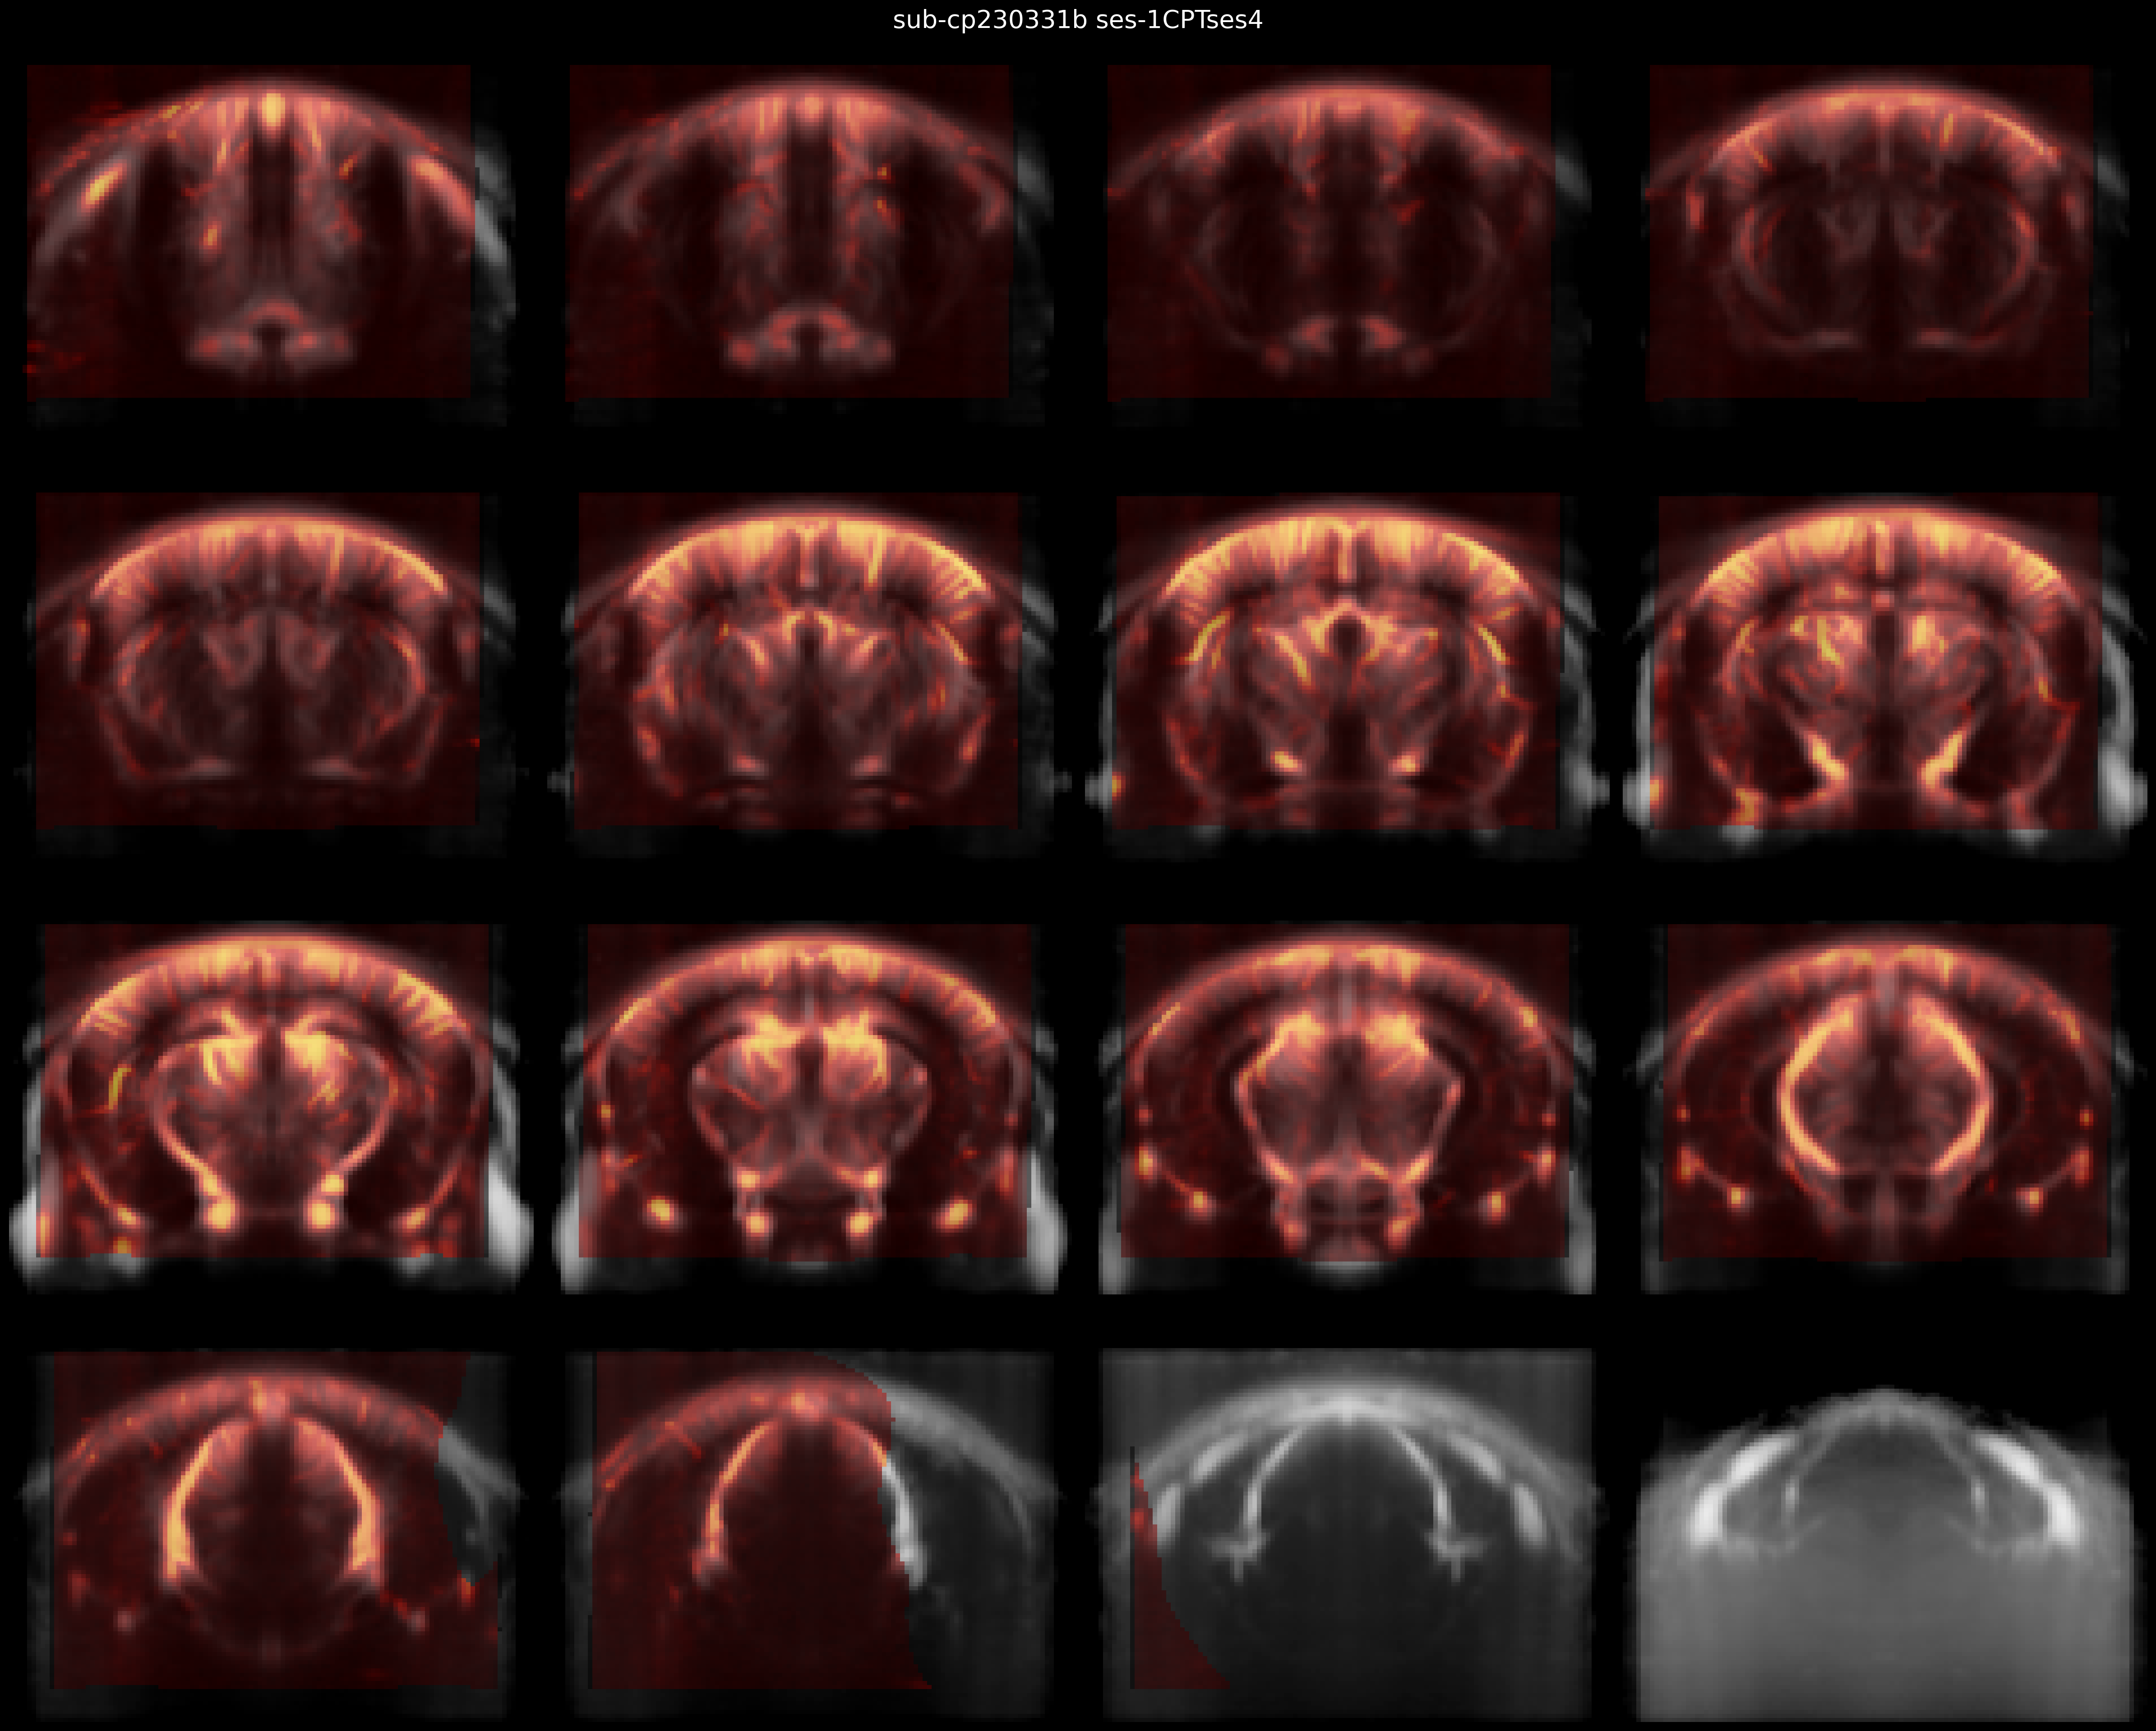

In [172]:
fig = display_overlay(
    img,
    template_img,
    title = title
)

In [157]:
localmask_path = [x for x in file_name.parent.iterdir() if x.is_file() and re.match(f'^.*mask.nii.gz$', x.name)][0]
localmask_img = nib.load(localmask_path)

original_path = [x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{file_name.name.split('proc')[0]}.*.nii.gz$', x.name)][0]
original_img = nib.load(original_path)

/tmp/ipykernel_2140099/2537340053.py:18: RuntimeWarning: divide by zero encountered in log10
  img_2_display = np.log10(bg_img.get_fdata()[slice_id,:,:])


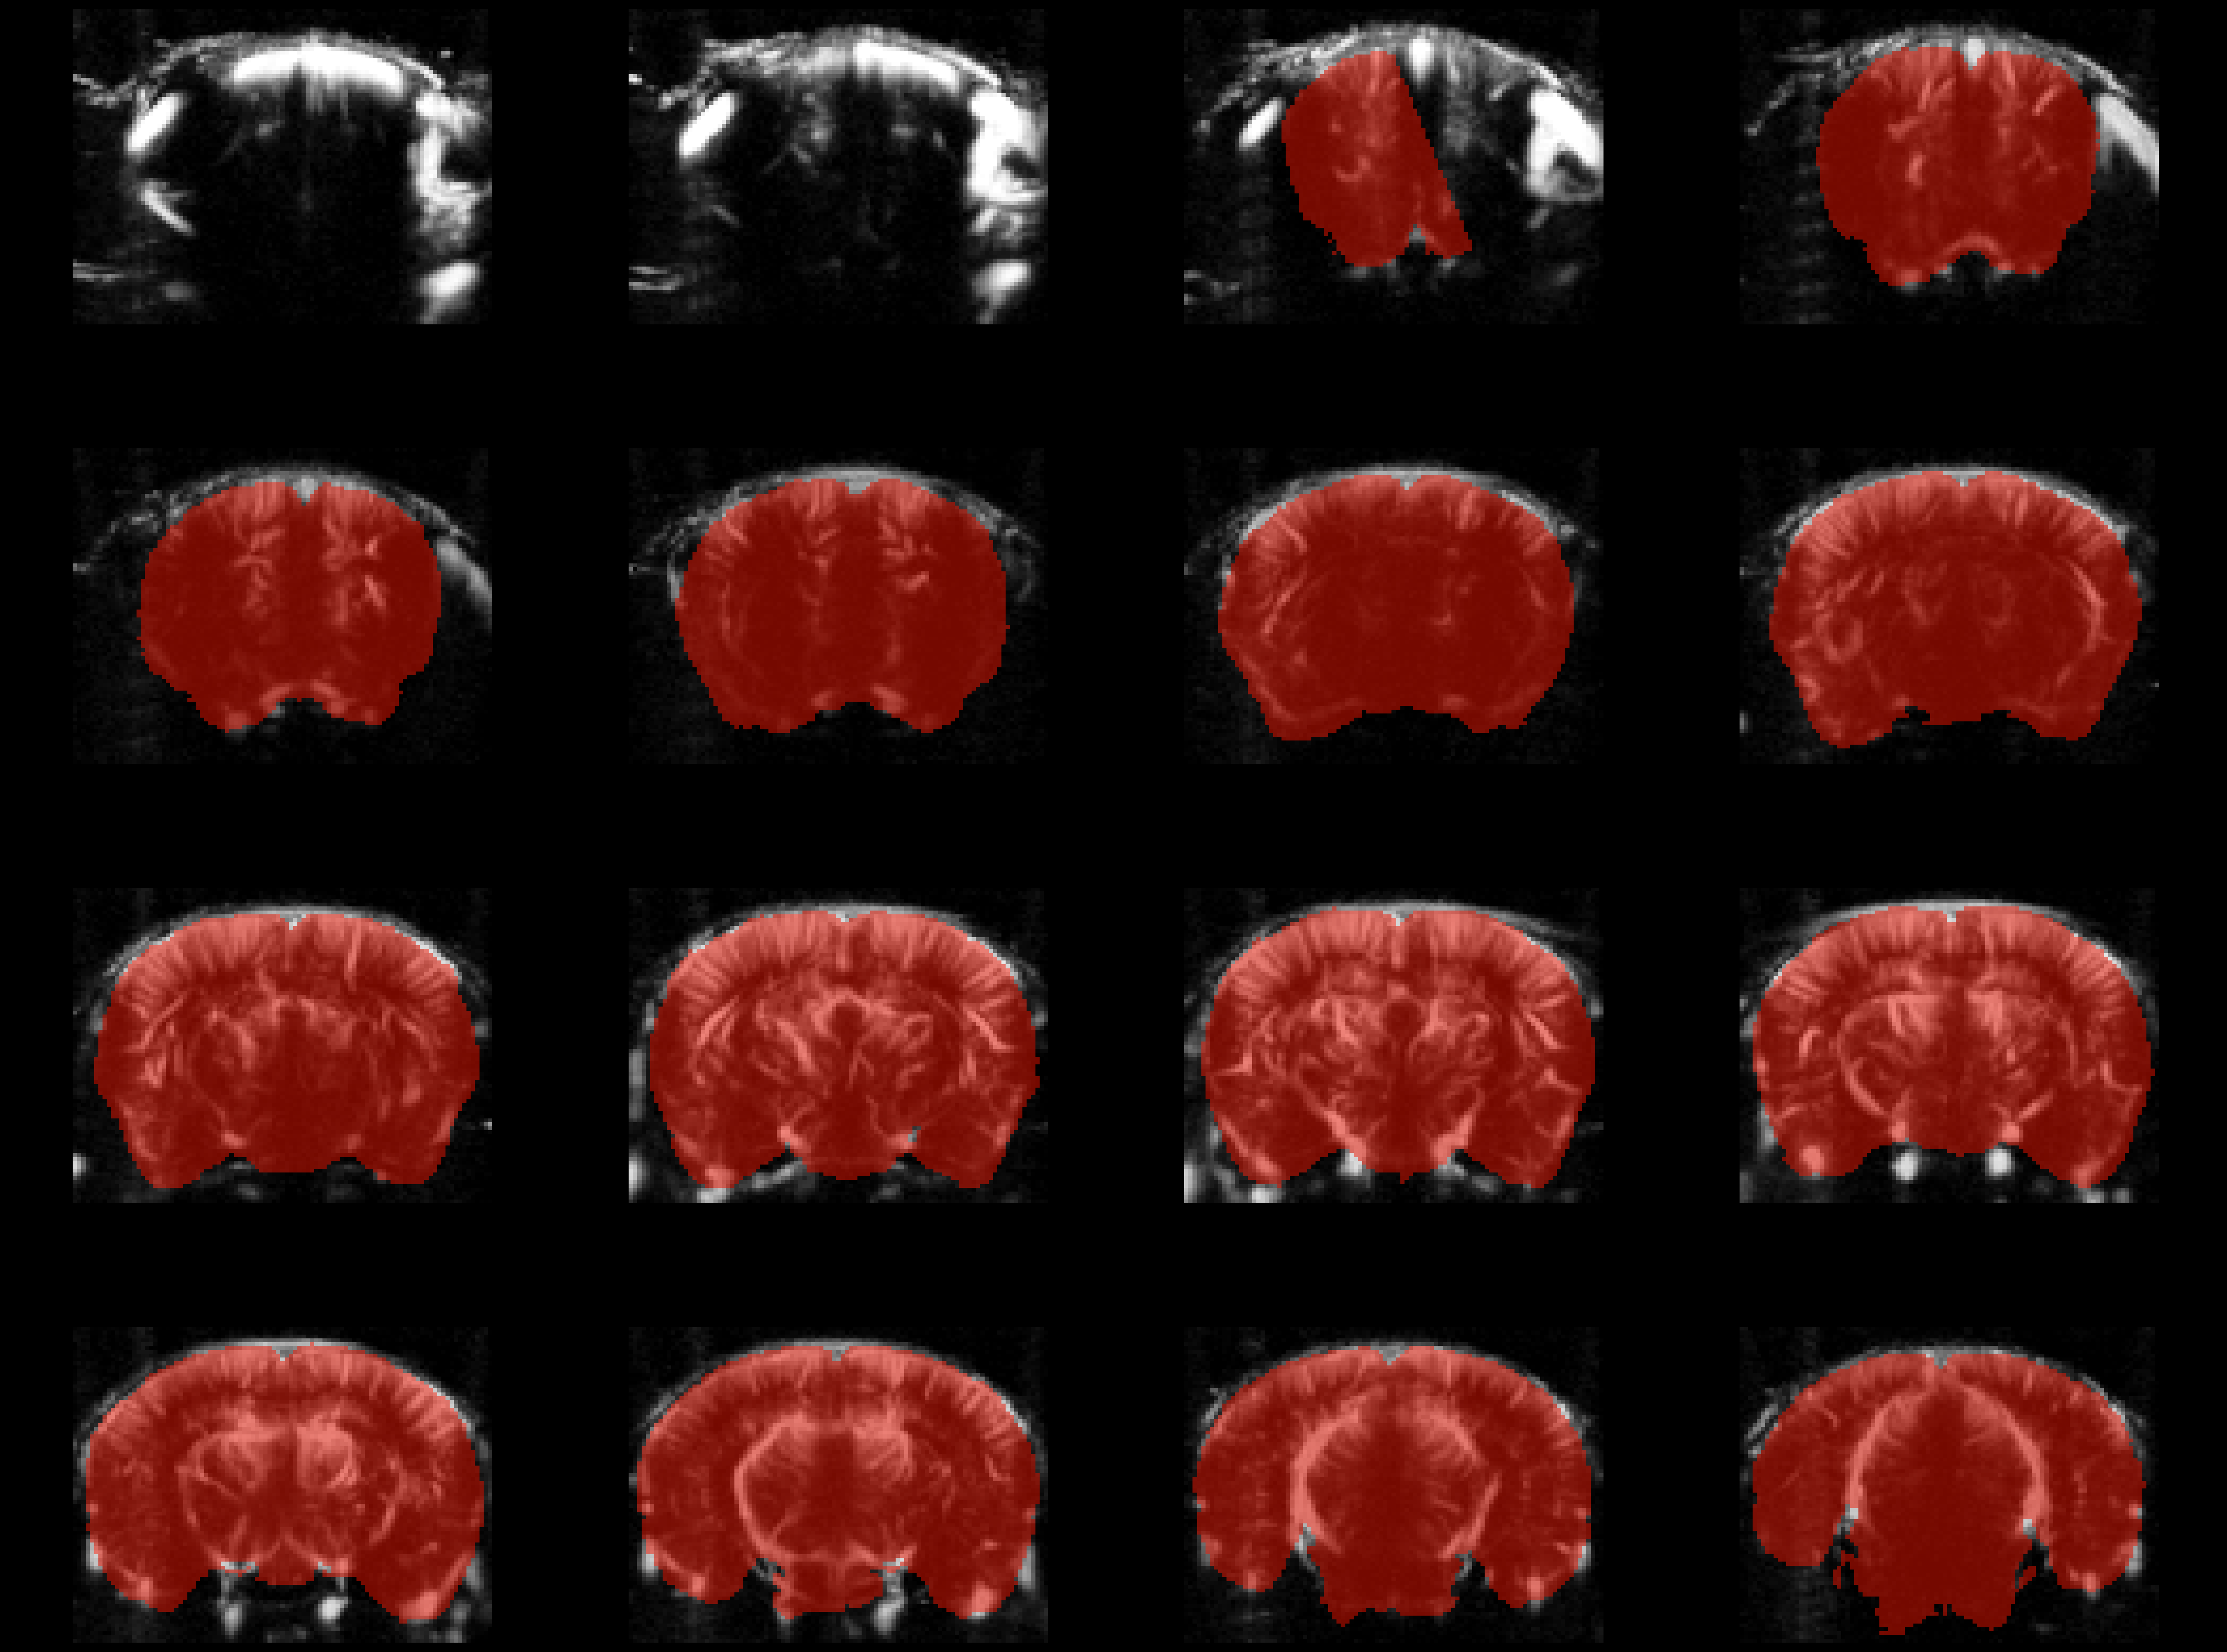

In [160]:
fig = display_overlay(
    localmask_img,
    original_img,
    slice_ids = np.linspace(5,75,16).astype(int),
    nb_col = 4,
    vmin = 0.7,
    vmax = 2.2,
    flag_mask=True
)

## AntsRegistration

### single file

In [ ]:
file_id = 23
file_name = root_dir[file_id]

prefix = 'proc-registeredSyN_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

# Computes the transform

transformation_path = compute_registration(
    file_name, 
    ref_name, 
    temp_dir, 
    registration_type = 'SyN', 
    prefix = prefix,
    write_composite_transform = True,
    num_threads = 18,
)

# Apply the transform

registered_name = apply_transformation(
    file_name, 
    ref_name, 
    transformation_path,
    temp_dir,
    prefix = prefix,
    interpolation = 'Linear'
)

# Back transforms the mask

retrotransformation_path = transformation_path.parent / (transformation_path.name.split('Composite')[0] + 'InverseComposite.h5')

prefix = 'proc-registeredSyNinv_mask'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

retromask_name = apply_transformation(
    mask_name, 
    file_name, 
    retrotransformation_path,
    temp_dir,
    prefix = prefix,
    interpolation = 'NearestNeighbor'
)

clean_file(
    file_name,
    save_path, 
    temp_dir
)

### Test line by line

In [76]:
file_id = 42
file_name = root_dir[file_id]

prefix = 'proc-registeredSyN_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
print(prefix)

sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredSyN_pwd


In [49]:
transformation_path = compute_registration(
    file_name, 
    ref_name, 
    temp_dir, 
    registration_type = 'SyN', 
    prefix = prefix,
    write_composite_transform = True,
    num_threads = 18,
)

antsRegistration --collapse-output-transforms 0 --dimensionality 3 --initial-moving-transform [ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_pwd.nii.gz, 1 ] --initialize-transforms-per-stage 0 --interpolation Linear --output /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_ --transform Rigid[ 0.1 ] --metric MI[ /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz, /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdat

In [50]:
transformation_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_Composite.h5')

In [51]:
save_name = apply_transformation(
    file_name, 
    ref_name, 
    transformation_path,
    temp_dir,
    prefix = prefix,
    interpolation = 'Linear'
)

In [77]:
transformation_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredSyN_pwd_InverseComposite.h5')
prefix = 'proc-registeredSyNinv_mask'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

ref_name = root_dir[file_id]
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')


In [79]:
save_name = apply_transformation(
    file_name, 
    ref_name, 
    transformation_path,
    temp_dir,
    prefix = prefix,
    interpolation = 'NearestNeighbor'
)

## FLIRT registration
    

    

In [25]:
from nipype.interfaces import fsl

def compute_transform_flirt(
    file_name,
    ref_name,
    save_dir
):

    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)
    
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.out_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd.nii.gz')) 
    flt.inputs.out_matrix_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat'))
    print(flt.cmdline)
    res = flt.run()

    return save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat')

def apply_transform_flirt(
    file_name,
    ref_name,
    transformation_path,
    save_dir,
    prefix = None,
    interp = 'spline'
):

    if prefix is None:
        perfix = (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd')
    
    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)

    flt.inputs.apply_xfm = True
    flt.inputs.in_matrix_file = transformation_path
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.interp = interp
    flt.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    print(flt.cmdline)
    res = flt.run()

    return f'{prefix}.nii.gz'

In [8]:
file_id = 42
file_name = root_dir[file_id]

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

prefix = 'proc-registeredSyN_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
print(prefix)

save_dir = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')
save_folder = save_dir / file_name.parent.parent.name / file_name.parent.name
save_folder.mkdir(exist_ok = True, parents = True)

sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredSyN_pwd


In [9]:
compute_transform_flirt(
    file_name,
    ref_name,
    save_folder
)

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_pwd.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredFLIRT_pwd.nii.gz -omat /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_registrationMatrix.mat


PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registered_pwd.nii.gz')

In [203]:
transformation_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_registrationMatrixInversed.mat')

In [23]:
apply_transform_flirt(
    mask_name,
    file_name,
    transformation_path,
    save_folder,
    interp='nearestneighbour',
    prefix = file_name.name.split('_pwd')[0] + '_proc-registeredFLIRTinv_mask'
)

flirt -in /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz -ref /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_pwd.nii.gz -out /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredFLIRTinv_mask.nii.gz -omat source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature_flirt.mat -applyxfm -init /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/test_inv.mat -interp nearestneighbour


'sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_proc-registeredFLIRTinv_mask.nii.gz'

In [10]:
data = []

transformation_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_registrationMatrix.mat')

with open(transformation_path, 'r') as f:

    for line in f.readlines():

        data.append([float(x) for x in line.split(' \n')[0].split('  ')])

direct_matrix = np.array(data)

data = []

transformation_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/test_inv.mat')

with open(transformation_path, 'r') as f:

    for line in f.readlines():

        data.append([float(x) for x in line.split(' \n')[0].split('  ')])

inverse_matrix = np.array(data)

print(direct_matrix)
print('\n\n')
print(inverse_matrix)


[[ 0.97536795  0.11475929  0.00895314  0.77906254]
 [-0.17853014  1.02112745 -0.03883187  0.64028146]
 [-0.00733925  0.03512221  0.97154882 -0.67315355]
 [ 0.          0.          0.          1.        ]]



[[ 1.00457237 -0.11242578 -0.01375101 -0.7198971 ]
 [ 0.17568277  0.95830385  0.03668351 -0.72575842]
 [ 0.00123765 -0.03549268  1.02785434  0.7136649 ]
 [ 0.          0.          0.          1.        ]]


In [14]:
from fsl.wrappers.flirt import invxfm

In [15]:
invxfm(
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_registrationMatrix.mat'),
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230511a/ses-1CPTses9/sub-cp230511a_ses-1CPTses9_acq-3Dscan_probe-linear_registrationMatrixInversed.mat')
)

{}

In [232]:
T = direct_matrix[:3, -1]
print(T)

[ 0.77906254  0.64028146 -0.67315355]


## FNIRT registration

In [141]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

# Required parameters for blown up transforms

template_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

flirt_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')

# checks

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

# output

save_dir = root_path.parent / 'derivatives' / 'registered-fnirt'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files
sub-cp230328a_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230328b_ses-1CPTses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329a_ses-1MEDISOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230329b_ses-1CPTses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230330a_ses-1CPTses3_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331a_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230331b_ses-1CPTses4_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405a_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405b_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230405c_ses-1MEDISOses2_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406a_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230406b_ses-1HALOses1_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412a_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412b_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230412c_ses-1CPTses5_acq-3Dscan_probe-linear_pwd.nii.gz
sub-cp230413a_ses-1HALOses2_acq-3Dscan

### Single file

In [292]:
template_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

flirt_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')

In [293]:
save_path

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-fnirt')

In [296]:
t0 = time()

file_name = root_dir[28]

######################################################### Starts

prefix = 'proc-blownupRegisteredFNIRT_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

subject_session = '_'.join(file_name.name.split('_')[:3])
affine_initialisation = sorted([x for x in flirt_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*registrationMatrix.mat$', x.name)])[0]

# Blows up original image x10 for FSL integer

img_temp = nib.load(file_name)

new_affine = 10*img_temp.affine.copy()
new_affine[-1,-1] = 1

img_temp = nib.Nifti1Image(
    img_temp.get_fdata(),
    affine = new_affine
)

file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')

nib.save(
    img_temp,
    file_blownup_name
)

# transforms the blown up image

registered_path, transformation_path = compute_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    temp_dir,
    prefix,
    affine_initialisation
)

# applies the transform to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])

for file_path in file_dir:

    local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredFNIRT_sliceMask')
    
    # Blows up the image

    img_temp = nib.load(file_path)

    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_path
    )

    apply_transform_fnirt(
        file_blownup_path,
        template_blownup_name,
        transformation_path,
        temp_dir,
        local_prefix,
        interp = 'nn'
    )

# inverses the tranform

inverse_transformation_path = inverse_transform_fnirt(
    transformation_path,
    template_blownup_name
)

# Apply the transform to blown up mask for retromasking

apply_transform_fnirt(
    mask_blownup_name,
    file_blownup_name,
    inverse_transformation_path,
    temp_dir,
    interp='nn',
    prefix = file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredFNIRTinv_mask'
)

# downsample back the results

downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredFNIRT.*.nii.gz$', x.name)])

to_keep_files = []

for file_blownup_path in downsample_dir:
    
    img_temp = nib.load(file_blownup_path)

    new_affine = img_temp.affine.copy()/10
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blowndown_path = temp_dir / 'registeredFNIRT'.join(file_blownup_path.name.split('blownupRegisteredFNIRT'))
    
    nib.save(
        img_temp,
        file_blowndown_path
    )

    to_keep_files.append(file_blowndown_path)

# delete intermediary files

for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
    
    if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownup_pwd.*.nii.gz$', x.name)])):

        local_file_name.unlink()

# retrieve the files

clean_file(
    file_name,
    save_path, 
    temp_dir
)

######################################################### Done

print(f'It took {time()-t0:.2f}s')

250425-17:26:47,153 nipype.interface INFO:
	 stdout 2025-04-25T17:26:47.153808:Warning, Jacobian not within prescribed range. Prescription is 0.01 -- 100 and obtained range is 0.00510127 -- 7.81777
It took 845.08s


In [265]:
img_temp = nib.load(mask_name)

new_affine = 10*img_temp.affine.copy()
new_affine[-1,-1] = 1

img_temp = nib.Nifti1Image(
    img_temp.get_fdata(),
    affine = new_affine
)

nib.save(
    img_temp,
    mask_name.parent / (mask_name.name.split('110umx100umx100um')[0] + '1100umx1000umx1000um_feature.nii.gz')
)

In [267]:
template_blownup_name = template_name.parent / (template_name.name.split('110umx100umx100um')[0] + '1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

In [266]:
template_name

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

In [288]:
file_name = root_dir[48]

prefix = 'proc-blownupRegisteredFNIRT_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
print(prefix)


sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownupRegisteredFNIRT_pwd


In [203]:
flirt_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/')

subject_session = '_'.join(file_name.name.split('_')[:3])

affine_initialisation = sorted([x for x in flirt_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*registrationMatrix.mat$', x.name)])[0]

print(affine_initialisation)

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230515a/ses-1CPTses11/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_registrationMatrix.mat


In [204]:
img_temp = nib.load(file_name)

new_affine = 10*img_temp.affine.copy()
new_affine[-1,-1] = 1

img_temp = nib.Nifti1Image(
    img_temp.get_fdata(),
    affine = new_affine
)

file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')

nib.save(
    img_temp,
    temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')
)

In [262]:
def compute_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    save_dir,
    prefix,
    affine_initialisation
):
    
    fnirt_mprage = fsl.FNIRT()
    fnirt_mprage.inputs.affine_file=affine_initialisation
    fnirt_mprage.inputs.in_file=file_blownup_name
    fnirt_mprage.inputs.ref_file=template_blownup_name
    fnirt_mprage.inputs.warped_file=str(save_dir / (prefix + '.nii.gz'))
    fnirt_mprage.inputs.in_fwhm = [8, 4, 2, 2]
    fnirt_mprage.inputs.subsampling_scheme = [4, 2, 1, 1]
    fnirt_mprage.inputs.regularization_lambda = [200, 75, 40, 20]
    
    fnirt_mprage.inputs.warp_resolution = (5,5,5)
    
    fnirt_mprage.cmdline

    fnirt_mprage.run()

    return save_dir / (prefix + '.nii.gz'), save_dir / (file_blownup_name.name.split('.nii.gz')[0] + '_warpcoef.nii.gz') 

def apply_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    transformation_path,
    save_dir,
    prefix,
    interp = 'trilinear'
):
    
    aw = fsl.ApplyWarp()
    aw.inputs.in_file = str(file_blownup_name)
    aw.inputs.ref_file = str(template_blownup_name)
    aw.inputs.field_file = str(transformation_path)
    aw.inputs.out_file = str(save_dir / (prefix + '.nii.gz'))
    aw.inputs.interp = interp

    aw.cmdline

    aw.run()

    return save_dir / (prefix + '.nii.gz')

def inverse_transform_fnirt(
    transformation_path,
    ref_img
):

    invwarp = InvWarp()
    invwarp.inputs.warp = transformation_path
    invwarp.inputs.reference = ref_img
    invwarp.inputs.output_type = "NIFTI_GZ"
    invwarp.inputs.inverse_warp = str(transformation_path.parent / (transformation_path.name.split('.nii.gz')[0] + 'Inv.nii.gz'))
    
    invwarp.cmdline

    invwarp.run() 

    return transformation_path.parent / (transformation_path.name.split('.nii.gz')[0] + 'Inv.nii.gz')

In [210]:
registered_path = compute_transform_fnirt(
    file_blownup_name,
    template_blownup_name,
    temp_dir,
    prefix,
    affine_initialisation
)

NameError: name 'save_dir_dir' is not defined

In [243]:
fnirt_mprage.cmdline

'fnirt --aff=/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-flirt/sub-cp230515a/ses-1CPTses11/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_registrationMatrix.mat --in=/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownup_pwd.nii.gz --infwhm=8,4,2,2 --intmod=local_non_linear --logout=/home/jmariani/Documents/python/fUS-analysis/standardized/re-analysis_Pepe-Mariani/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownup_pwd_log.txt --ref=/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz --lambda=200.0,75.0,40.0,20.0 --subsamp=4,2,1,1 --warpres=5,5,5 --iout=/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dsc

In [230]:
registered_path = temp_dir / (prefix + '.nii.gz')
print(registered_path)

transformation_path = temp_dir / (file_blownup_name.name.split('.nii.gz')[0] + '_warpcoef.nii.gz') 
print(transformation_path)

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownupRegisteredFNIRT_pwd.nii.gz
/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownup_pwd_warpcoef.nii.gz


In [ ]:
# applies the transform to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])

for file_path in file_dir:

    local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredFNIRT_sliceMask')
    
    # Blows up the image

    img_temp = nib.load(file_path)

    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_path
    )

    apply_transform_fnirt(
        file_blownup_path,
        template_blownup_name,
        transformation_path,
        temp_dir,
        local_prefix,
        interp = 'nn'
    )

In [263]:
# inverses the tranform

inverse_transformation_path = inverse_transform_fnirt(
    transformation_path,
    template_blownup_name
)

In [268]:
# Apply the transform for retromasking

apply_transform_fnirt(
    mask_blownup_name,
    file_blownup_name,
    inverse_transformation_path,
    temp_dir,
    interp='nn',
    prefix = file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredFNIRTinv_mask'
)

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-blownupRegisteredFNIRTinv_mask.nii.gz')

In [277]:
# downsample the results

downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredFNIRT.*.nii.gz$', x.name)])

to_keep_files = []

for file_blownup_path in downsample_dir:
    
    img_temp = nib.load(file_blownup_path)

    new_affine = img_temp.affine.copy()/10
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blowndown_path = temp_dir / 'registeredFNIRT'.join(file_blownup_path.name.split('blownupRegisteredFNIRT'))
    
    nib.save(
        img_temp,
        file_blowndown_path
    )

    to_keep_files.append(file_blowndown_path)

In [280]:
to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownup_pwd.*.nii.gz$', x.name)])

[PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredFNIRT_pwd.nii.gz'),
 PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_acq-3Dscan_probe-linear_proc-registeredFNIRTinv_mask.nii.gz'),
 PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-0_proc-registeredFNIRT_sliceMask.nii.gz'),
 PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-1_proc-registeredFNIRT_sliceMask.nii.gz'),
 PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230515a_ses-1CPTses11_task-rest_acq-3Dfus_probe-linear_pose-2_proc-regist

In [287]:
# delete intermediary files

for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
    
    if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownup_pwd.*.nii.gz$', x.name)])):

        local_file_name.unlink()

In [289]:
# retrieve the files

clean_file(
    file_name,
    save_path, 
    temp_dir
)

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp')

In [ ]:

def compute_transform_flirt(
    file_name,
    ref_name,
    save_dir
):

    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)
    
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.out_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd.nii.gz')) 
    flt.inputs.out_matrix_file = str(save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat'))
    print(flt.cmdline)
    res = flt.run()

    return save_dir / (file_name.name.split('_pwd')[0] + '_registrationMatrix.mat')

def apply_transform_flirt(
    file_name,
    ref_name,
    transformation_path,
    save_dir,
    prefix = None,
    interp = 'spline'
):

    if prefix is None:
        perfix = (file_name.name.split('_pwd')[0] + '_proc-registeredFLIRT_pwd')
    
    flt = FLIRT()
    flt.inputs.in_file = str(file_name)
    flt.inputs.reference = str(ref_name)

    flt.inputs.apply_xfm = True
    flt.inputs.in_matrix_file = transformation_path
    flt.inputs.output_type = "NIFTI_GZ"
    flt.inputs.interp = interp
    flt.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    print(flt.cmdline)
    res = flt.run()

    return f'{prefix}.nii.gz'

## AFNI

### single file

In [ ]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

for file_name in root_dir:

    print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-afni'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

In [134]:
file_name = root_dir[37]

prefix = 'proc-registered3dAllineate_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]
    
local_file_name, param_path = compute_registration_afni(
    file_name,
    template_name,
    temp_dir,
    prefix
)

# applies the transform to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])


for file_path in file_dir:

    local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-registeredAFNIwarp_sliceMask')

    apply_transform_afni(
        file_path,
        template_name,
        temp_dir,
        local_prefix,
        param_name = param_path
    )

# big hack to transform back the mask

prefix = 'proc-registered3dAllineateInvback_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

retro_name, param_path = compute_registration_afni(
    local_file_name,
    file_name,
    temp_dir,
    prefix
)

# applies the retro transform to volume masks

prefix = file_name.name.split('_pwd')[0] + '_proc-registeredAFNIinv_mask'

apply_transform_afni(
    mask_name,
    file_name,
    temp_dir,
    prefix,
    param_name = param_path,
    interp = 'nearestneighbour'
)

# clean the output folder

clean_file(
    file_name,
    save_path, 
    temp_dir
)

250424-21:15:05,249 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.249854:++ 3dAllineate: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250424-21:15:05,250 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.249854:++ Authored by: Zhark the Registrator
250424-21:15:05,252 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.252539:++ Option '-cmass' enables center-of-mass code = 7 = +xyz
250424-21:15:05,253 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.252539:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/sub-cp230509b/ses-1HALOses7/sub-cp230509b_ses-1HALOses7_acq-3Dscan_probe-linear_pwd.nii.gz to FLOAT32
250424-21:15:05,254 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.252539:     Warnings of this type will be muted for this session.
250424-21:15:05,255 nipype.interface INFO:
	 stderr 2025-04-24T21:15:05.252539:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see non

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp')

# 3dQwarp 

In [333]:
root_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

ref_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')
mask_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')


# Required parameters for blown up transforms

template_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz')
mask_blownup_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz')

afni_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/')

print(f'We found {len(root_dir)} files')

# for file_name in root_dir:

#     print(file_name.name)

save_dir = root_path.parent / 'derivatives' / 'registered-afniWarp'
save_dir.mkdir(exist_ok = True, parents = True)
temp_dir = root_path.parent / 'derivatives' / 'temp'
temp_dir.mkdir(exist_ok = True, parents = True)

save_path = save_dir

We found 50 files


## Single file

In [382]:
def compute_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix
):
    
    qwarp = afni.Qwarp()
    qwarp.inputs.in_file = file_name
    qwarp.inputs.base_file = template_name
    qwarp.inputs.out_file = str(save_dir / f'{prefix}.nii.gz') 
    qwarp.inputs.resample = True
    qwarp.inputs.lpa = True
    qwarp.inputs.iwarp = True
    qwarp.inputs.allineate = True
    qwarp.inputs.allineate_opts = "-com -cost lpa -autoweight +10"
    qwarp.inputs.blur = [0,-3]
    qwarp.inputs.minpatch = 10
    qwarp.inputs.num_threads = 18
    qwarp.inputs.quiet = True  
    
    qwarp.cmdline

    qwarp.run()
    
    return save_dir / f'{prefix}.nii.gz'


def apply_transform_qwarp(
    file_name,
    template_name,
    save_dir,
    prefix,
    transformation_path,
    interp = 'tri-linear'
):
    
    nwarp = afni.NwarpApply()
    nwarp.inputs.in_file = file_name
    nwarp.inputs.master = template_name
    nwarp.inputs.warp = str(transformation_path)
    nwarp.inputs.out_file = save_dir / f'{prefix}.nii.gz'
    nwarp.inputs.interp = interp
    nwarp.inputs.quiet = True
    nwarp.cmdline
    
    res = nwarp.run() 
    
    return save_dir / f'{prefix}.nii.gz'



In [ ]:
t0 = time()

file_id = 3
file_name = root_dir[file_id]

prefix = 'proc-blownupRegisteredQwarp_pwd'.join(file_name.name.split('pwd')).split('.nii.gz')[0]

subject_session = '_'.join(file_name.name.split('_')[:3])
affine_initialisation = sorted([x for x in afni_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*warp.param.1D$', x.name)])[0]

# Blows up original image x10 for integer 

img_temp = nib.load(file_name)

new_affine = 10*img_temp.affine.copy()
new_affine[-1,-1] = 1

img_temp = nib.Nifti1Image(
    img_temp.get_fdata(),
    affine = new_affine
)

file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')

nib.save(
    img_temp,
    file_blownup_name
)

# Computes the transform

registered_path = compute_transform_qwarp(
    file_blownup_name,
    template_blownup_name,
    temp_dir,
    prefix
) 

transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARP.nii.gz')

# Applies transformation to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])

for file_path in file_dir:

    local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredQwarp_sliceMask')
    
    # Blows up the image

    img_temp = nib.load(file_path)

    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_path
    )

    apply_transform_qwarp(
        file_blownup_path,
        template_blownup_name,
        temp_dir,
        local_prefix,
        transformation_path,
        interp = 'NN'
    )

# Applies the transform to blown up mask for retromasking

inverse_transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARPINV.nii.gz')

apply_transform_qwarp(
        mask_blownup_name,
        file_blownup_name,
        temp_dir,
        file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredQwarpInv_mask',
        inverse_transformation_path,
        interp = 'NN'
    )

# downsample back the results

downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredQwarp(_pwd|Inv_mask|_sliceMask).nii.gz$', x.name)])

for x in downsample_dir:

    print(x.name)

to_keep_files = []

for file_blownup_path in downsample_dir:
    
    img_temp = nib.load(file_blownup_path)

    new_affine = img_temp.affine.copy()/10
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blowndown_path = temp_dir / 'registeredQwarp'.join(file_blownup_path.name.split('blownupRegisteredQwarp'))
    
    nib.save(
        img_temp,
        file_blowndown_path
    )

    to_keep_files.append(file_blowndown_path)

# delete intermediary files

for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
    
    if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*(proc-blownup_pwd|_Allin|WARP).*.nii.*$', x.name)])):

        local_file_name.unlink()

# retrieve the files

clean_file(
    file_name,
    save_path, 
    temp_dir
)

######################################################### Done

print(f'It lasted {time()-t0:.2f}s')

250428-22:14:15,382 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.382184:++ OpenMP thread count = 18
250428-22:14:15,383 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.383285:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250428-22:14:15,383 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.383285:++ Authored by: Zhark the (Hermite) Cubically Warped
250428-22:14:15,385 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.385408:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz to FLOAT32
250428-22:14:15,386 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.385408:     Warnings of this type will be muted for this session.
250428-22:14:15,386 nipype.interface INFO:
	 stderr 2025-04-28T22:14:15.385408:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
2504

In [320]:
subject_session = '_'.join(file_name.name.split('_')[:3])
affine_initialisation = sorted([x for x in afni_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*warp.param.1D$', x.name)])[0]

In [321]:
print(affine_initialisation)

/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-afni/sub-cp230511b/ses-1HALOses9/sub-cp230511b_ses-1HALOses9_acq-3Dscan_probe-linear_proc-registered3dAllineateInvback_warp.param.1D


In [332]:
# Blows up original image x10 for integer 

img_temp = nib.load(file_name)

new_affine = 10*img_temp.affine.copy()
new_affine[-1,-1] = 1

img_temp = nib.Nifti1Image(
    img_temp.get_fdata(),
    affine = new_affine
)

file_blownup_name = temp_dir / (file_name.name.split('pwd')[0] + 'proc-blownup_pwd.nii.gz')

nib.save(
    img_temp,
    file_blownup_name
)

In [ ]:
qwarp.run()

250428-19:55:22,43 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.043908:++ OpenMP thread count = 18
250428-19:55:22,45 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.045449:++ 3dQwarp: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250428-19:55:22,46 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.045449:++ Authored by: Zhark the (Hermite) Cubically Warped
250428-19:55:22,47 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.047691:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-1100umx1000umx1000um_feature.nii.gz to FLOAT32
250428-19:55:22,48 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.047691:     Warnings of this type will be muted for this session.
250428-19:55:22,49 nipype.interface INFO:
	 stderr 2025-04-28T19:55:22.047691:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
250428-19:

In [342]:
registered_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230511b_ses-1HALOses9_acq-3Dscan_probe-linear_registrationBlownupQwarp.nii.gz')

In [344]:
transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARP.nii.gz')

In [ ]:
# applies the transform to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])
print(f'We found {len(file_dir)} files')

# applies the transform to slice masks

subject_session = '_'.join(file_name.name.split('_')[:2])
file_dir = sorted([x for x in root_path.rglob('*') if x.is_file() and re.match(f'^.*{subject_session}.*pose.*.nii.gz$', x.name)])

for file_path in file_dir:

    local_prefix = (file_path.name.split('sliceMask')[0] + 'proc-blownupRegisteredQwarp_sliceMask')
    
    # Blows up the image

    img_temp = nib.load(file_path)

    new_affine = 10*img_temp.affine.copy()
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blownup_path = temp_dir / (file_path.name.split('sliceMask')[0] + 'proc-blownup_sliceMask.nii.gz')
    
    nib.save(
        img_temp,
        file_blownup_path
    )

    apply_transform_qwarp(
        file_blownup_path,
        template_blownup_name,
        temp_dir,
        local_prefix,
        transformation_path,
        interp = 'NN'
    )

In [355]:
# Apply the transform to blown up mask for retromasking

inverse_transformation_path = registered_path.parent / (registered_path.name.split('.nii.gz')[0] + '_WARPINV.nii.gz')

apply_transform_qwarp(
        mask_blownup_name,
        file_blownup_name,
        temp_dir,
        file_name.name.split('_pwd')[0] + '_proc-blownupRegisteredQwarpInv_mask',
        inverse_transformation_path,
        interp = 'NN'
    )


250428-21:10:17,894 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.894029:++ 3dNwarpApply: AFNI version=AFNI_24.0.12 (Mar 12 2024) [64-bit]
250428-21:10:17,895 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.894029:++ Authored by: Zhark the Warped
250428-21:10:17,907 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.907892:** AFNI converts NIFTI_datatype=64 (FLOAT64) in file /media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-1100umx1000umx1000um_feature.nii.gz to FLOAT32
250428-21:10:17,908 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.907892:     Warnings of this type will be muted for this session.
250428-21:10:17,909 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.907892:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
250428-21:10:17,916 nipype.interface INFO:
	 stderr 2025-04-28T21:10:17.915979:++ opened source dataset '/media/DATA2/JC/1_DAT

PosixPath('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/temp/sub-cp230511b_ses-1HALOses9_acq-3Dscan_probe-linear_proc-blownupRegisteredQwarpInv_mask.nii.gz')

In [356]:
# downsample back the results

downsample_dir = sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownupRegisteredQwarp.*.nii.gz$', x.name)])

for x in downsample_dir:

    print(x.name)

sub-cp230511b_ses-1HALOses9_acq-3Dscan_probe-linear_proc-blownupRegisteredQwarpInv_mask.nii.gz
sub-cp230511b_ses-1HALOses9_task-rest_acq-3Dfus_probe-linear_pose-0_proc-blownupRegisteredQwarp_sliceMask.nii.gz
sub-cp230511b_ses-1HALOses9_task-rest_acq-3Dfus_probe-linear_pose-1_proc-blownupRegisteredQwarp_sliceMask.nii.gz
sub-cp230511b_ses-1HALOses9_task-rest_acq-3Dfus_probe-linear_pose-2_proc-blownupRegisteredQwarp_sliceMask.nii.gz
sub-cp230511b_ses-1HALOses9_task-rest_acq-3Dfus_probe-linear_pose-3_proc-blownupRegisteredQwarp_sliceMask.nii.gz


In [ ]:
to_keep_files = []

for file_blownup_path in downsample_dir:
    
    img_temp = nib.load(file_blownup_path)

    new_affine = img_temp.affine.copy()/10
    new_affine[-1,-1] = 1
    
    img_temp = nib.Nifti1Image(
        img_temp.get_fdata(),
        affine = new_affine
    )
    
    file_blowndown_path = temp_dir / 'registeredFNIRT'.join(file_blownup_path.name.split('blownupRegisteredFNIRT'))
    
    nib.save(
        img_temp,
        file_blowndown_path
    )

    to_keep_files.append(file_blowndown_path)

# delete intermediary files

for local_file_name in sorted([x for x in temp_dir.iterdir() if x.is_file()]):
    
    if not(local_file_name in to_keep_files + sorted([x for x in temp_dir.iterdir() if x.is_file() and re.match(f'^.*blownup_pwd.*.nii.gz$', x.name)])):

        local_file_name.unlink()

# retrieve the files

clean_file(
    file_name,
    save_path, 
    temp_dir
)

# Supplementaries

## Orientation of template

In [57]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/trash/Allen-100mu_fUS-space.nii.gz')
img = nib.load(file_name)

In [58]:
img.shape

(116, 81, 91)

In [59]:
img.affine

array([[0.11, 0.  , 0.  , 0.  ],
       [0.  , 0.1 , 0.  , 0.  ],
       [0.  , 0.  , 0.1 , 0.  ],
       [0.  , 0.  , 0.  , 1.  ]])

In [60]:
new_affine = np.diag([-0.1,-0.1,0.11,1.0])[[2,0,1,3],:]

img_out = nib.Nifti1Image(
    np.flip(img.get_fdata().transpose([1,2,0]), (0,1)),
    affine = new_affine
)

nib.save(
    img_out,
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenTemplate_res-110umx100umx100um_feature.nii.gz')
)

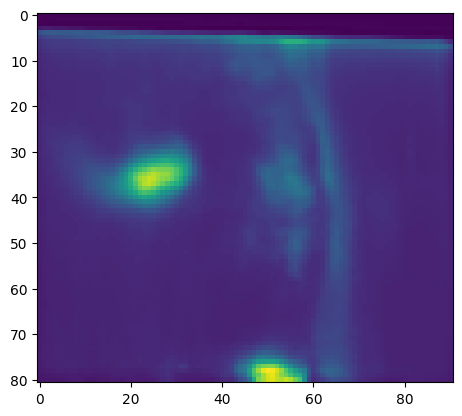

In [8]:
plt.imshow(img.get_fdata()[10,:,:])

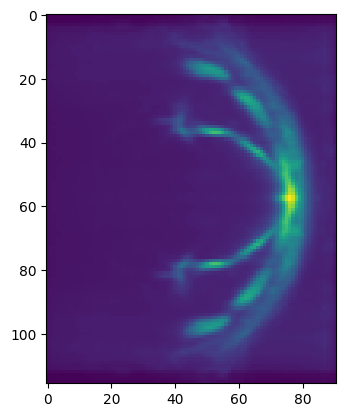

In [7]:
plt.imshow(img.get_fdata()[:,10,:])

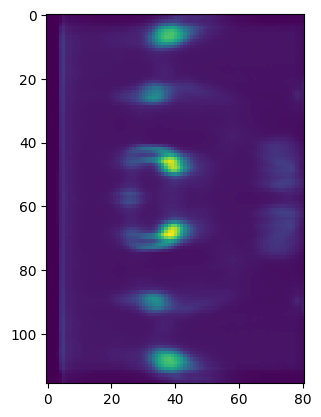

In [11]:
plt.imshow(img.get_fdata()[:,:,20])

### WMCSF

In [109]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/trash/WM-CSF-mask_reoriented_allen-space_centred_fUS-space_binerised.nii.gz')
img = nib.load(file_name)

In [110]:
new_affine = np.diag([-0.1,-0.1,0.11,1.0])[[2,0,1,3],:]

img_out = nib.Nifti1Image(
    np.flip(img.get_fdata().transpose([1,2,0]), (0,1)),
    affine = new_affine
)

nib.save(
    img_out,
    Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Gozzilab_space-fUSI_desc-WMCSFmask_res-110umx110umx100um_feature.nii.gz')
)

## Generate Mask 

In [71]:
file_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenTemplate_res-110umx100umx100um_feature.nii.gz')
img = nib.load(file_name)

img_data =  binary_fill_holes(img.get_fdata()>15).astype('uint32')

[X,Y,Z] = img_data.shape

for i in tqdm(range(X)):

    img_data[i,:,:] = getLargestCC(binary_fill_holes(img_data[i,:,:]))

mask_img = nib.Nifti1Image(
    img_data.astype('uint32'),
    affine = img.affine
)

save_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-Wang2020_space-fUSI_desc-AllenMask_res-110umx100umx100um_feature.nii.gz')

nib.save(
    mask_img,
    save_name
)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 81/81 [00:00<00:00, 880.98it/s]


In [68]:
from skimage.measure import label   

def getLargestCC(segmentation):
    labels = label(segmentation)
    assert( labels.max() != 0 ) # assume at least 1 CC
    largestCC = labels == np.argmax(np.bincount(labels.flat)[1:])+1
    return largestCC

## Retromasking

In [13]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')

root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*acq-3Dscan.*.nii.gz$', x.name)])

img = nib.load(root_dir[0])

[X,Y,Z] = img.shape

parameter_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/77_QCs/00_individual_checks/selection_slices_filled.csv')
pose_df = pd.read_csv(parameter_name)

pose_df.head()

print(f'We find {len(root_dir)} files')

# for x in root_dir:

#     print(x.name)

We find 50 files


In [18]:
for file_name in tqdm(root_dir):

    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]
    
    for pose in range(4):
    
        prefix = file_name.name.split('acq')[0] + f'task-rest_acq-3Dfus_probe-linear_pose-{pose}_sliceMask.nii.gz'
        
        slice_id = pose_df[(pose_df['subject'] == subject_name) & (pose_df['session'] == session_name)][f'pose-{pose}'].values[0]
    
        img_data = np.zeros((X,Y,Z))
        img_data[slice_id,:,:] = 1
        
        img_out = nib.Nifti1Image(
            img_data.astype('uint32'),
            affine = img.affine
        )
    
        save_name = root_name / file_name.parent.parent.name / file_name.parent.name / f'{prefix}'
        
        nib.save(
            img_out,
            save_name
        )

100%|████████████████████████████████| 50/50 [00:03<00:00, 12.63it/s]


### FLIRT

### FNIRT

### 3dAllineate

### 3dQwarp

### AntsRegistration Affine

### AntsRegistration SyN

### MINC

In [24]:
root_name = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/rawdata/')
root_dir = sorted([x for x in root_name.rglob('*') if x.is_file() and re.match(f'^.*pose.*sliceMask.nii.gz$', x.name)])

reference_path = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/Params/templates/source-BI_space-fUSI_desc-GillianTemplate_res-110umx100umx100um_feature.nii.gz')

print(f'We found {len(root_dir)} files')

transform_root = Path('/media/DATA2/JC/1_DATA/2025-02-24_PepeMariani/derivatives/00_3Dregistration/derivatives/registered-minc/')

We found 200 files


In [56]:
for file_name in tqdm(root_dir):

    # extract file name features
    
    subject_name = 'sub-' + file_name.name.split('sub-')[1].split('_')[0]
    session_name = 'ses-' + file_name.name.split('ses-')[1].split('_')[0]

    # gets the transform
    
    transform_path = sorted([x for x in transform_root.rglob('*') if x.is_file() and re.match(f'^.*{subject_name}.*{session_name}.*mat$', x.name)])[0]

    # generates apply tranform parameters
    
    output_dir = save_dir / file_name.parent.parent.name / file_name.parent.name
    prefix = file_name.name.split('sliceMask')[0] + f'proc-registeredMINC_slice_mask'
    
    # Apply the transform 

    apply_transformation_ants(
        file_name, 
        reference_path, 
        transform_path,
        output_dir,
        prefix = prefix,
        interpolation = 'NearestNeighbor',
        invert_transform_flag = [False]
    )

100%|██████████████████████████████| 200/200 [01:06<00:00,  3.00it/s]
